~1380 instead of 2841 — the other ~1460 lines are frontend assets or static requests, not backend API requests.


All HTTP methods included (GET, POST, PATCH, DELETE, etc.).

All status codes included.

Numeric IDs normalized to :id in endpoints.

Robust statistics: median, IQR-filtered mean, 95th percentile, max/min.

Outliers marked in plots.

Discarded lines saved in discarded_lines.csv for inspection.

Sorted by RobustMean(ms) so you immediately see slowest APIs.

#Log Analysis of API Response Times

This script analyzes an access log file (access.log) to evaluate the performance of API endpoints.

First, the code reads the log file and uses a regular expression to extract important information from each line, including the HTTP method, endpoint, status code, and response time (ms). Only requests that start with /api/ are considered for analysis, while other lines are recorded as discarded entries for inspection.

To ensure consistency, the script normalizes numeric IDs in endpoints (e.g., /api/users/123 → /api/users/:id) so that requests to similar endpoints are grouped together.

For each API endpoint, the code computes several performance statistics, including:

Total request count
Mean response time
Robust mean (calculated after removing outliers using the IQR method)
Median response time
95th percentile latency
Maximum and minimum response times
Associated HTTP status codes

All discarded log lines are saved into discarded_lines.csv for debugging.

Finally, the script visualizes response times for each API endpoint using plots. Each plot shows the sequence of response times, with outliers highlighted in red, allowing easy identification of unusual latency spikes.

This analysis helps identify slow APIs, outliers, and performance bottlenecks in the system.

In [ ]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
log_file_path = "access.log"

In [ ]:
# Generic regex: captures method, endpoint, status code, optional extra fields, response time
pattern = re.compile(r'(\S+)\s+(\S+)\s+(\d+).*?-\s+([\d\.]+)\s+ms')

In [ ]:
# Normalize numeric IDs in endpoints
def normalize_endpoint(endpoint):
    return re.sub(r'/\d+', '/:id', endpoint)

In [ ]:
# Collect data
api_data = {}
status_data = {}

all_lines_count = 0
api_lines_count = 0

discarded_lines = []

In [ ]:
with open(log_file_path, "r") as f:
    for line in f:
        all_lines_count += 1
        match = pattern.search(line)
        if match:
            method = match.group(1)
            endpoint = match.group(2)
            status = match.group(3)
            response_time = float(match.group(4))

            if not endpoint.startswith("/api/"):
                discarded_lines.append({"Line": line.strip(), "Reason": "Not /api/ endpoint"})
                continue

            api_lines_count += 1
            endpoint_norm = normalize_endpoint(endpoint)
            key = f"{method} {endpoint_norm}"

            api_data.setdefault(key, []).append(response_time)
            status_data.setdefault(key, []).append(status)
        else:
            discarded_lines.append({"Line": line.strip(), "Reason": "Regex did not match"})

In [ ]:
print(f"Total lines in file: {all_lines_count}")
print(f"Total /api/ lines captured: {api_lines_count}")
print(f"Total discarded lines: {len(discarded_lines)}")

Total lines in file: 2841
Total /api/ lines captured: 1380
Total discarded lines: 1461


In [ ]:
# Convert discarded lines to CSV for inspection if needed
df_discarded = pd.DataFrame(discarded_lines)
df_discarded.to_csv("discarded_lines.csv", index=False)

In [ ]:
# Compute statistics

data = []

for key, times in api_data.items():

    times_array = np.array(times)

    count = len(times)
    old_mean = times_array.mean()
    max_time = times_array.max()
    min_time = times_array.min()
    median_time = np.median(times_array)
    perc95 = np.percentile(times_array, 95)

    # IQR-based robust mean
    q1, q3 = np.percentile(times_array, [25,75])
    iqr = q3 - q1

    filtered_times = times_array[(times_array >= q1 - 1.5*iqr) & (times_array <= q3 + 1.5*iqr)]

    robust_mean = filtered_times.mean() if len(filtered_times) > 0 else np.nan

    data.append({
        "MethodEndpoint": key,
        "Count": count,
        "OldMean(ms)": old_mean,
        "RobustMean(ms)": robust_mean,
        "Median(ms)": median_time,
        "95thPerc(ms)": perc95,
        "MaxTime(ms)": max_time,
        "MinTime(ms)": min_time,
        "Statuses": status_data[key],
        "AllTimes": times
    })

In [ ]:
df = pd.DataFrame(data)

df_sorted = df.sort_values(by="RobustMean(ms)", ascending=False).reset_index(drop=True)

# Print top endpoints by robust mean
print(df_sorted[['MethodEndpoint','Count','OldMean(ms)','RobustMean(ms)','Median(ms)','95thPerc(ms)','MaxTime(ms)','MinTime(ms)','Statuses']])

                     MethodEndpoint  Count  OldMean(ms)  RobustMean(ms)  \
0              POST /api/auth/login     17    88.451647       88.451647   
1             POST /api/allocations      1    23.304000       23.304000   
2           POST /api/auth/register      7    42.520286       21.838500   
3              GET /api/members/:id     50    20.366960       18.235638   
4                  GET /api/members     70    20.055286       13.870935   
5              GET /api/allocations     70    17.473300       13.515359   
6                    GET /api/rooms     70    17.069357       13.394554   
7               GET /api/complaints     70    15.687329       12.705077   
8   GET /api/allocations/member/:id     50    13.422740       12.672000   
9           PATCH /api/visitors/:id      1    12.128000       12.128000   
10          DELETE /api/members/:id      6    18.226000       11.656800   
11                    GET /api/fees     70    15.398129       10.580500   
12   GET /api/complaints/

In [ ]:
# Plot function for each API with outliers marked
def plot_api_times(df):

    for _, row in df.iterrows():

        times = np.array(row['AllTimes'])
        key = row['MethodEndpoint']

        q1, q3 = np.percentile(times, [25,75])
        iqr = q3 - q1

        outliers = (times < q1 - 1.5*iqr) | (times > q3 + 1.5*iqr)

        plt.figure(figsize=(10,4))
        plt.plot(times, 'b-o', label='Response Time')
        plt.plot(np.where(outliers)[0], times[outliers], 'ro', markersize=6, label='Outliers')
        plt.title(f"Response Times for {key}")
        plt.xlabel("Request Index")
        plt.ylabel("Response Time (ms)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        print(f"Endpoint: {key}")
        print(f"  Count: {row['Count']}")
        print(f"  OldMean: {row['OldMean(ms)']:.3f} ms")
        print(f"  RobustMean: {row['RobustMean(ms)']:.3f} ms")
        print(f"  Median: {row['Median(ms)']:.3f} ms")
        print(f"  95th Percentile: {row['95thPerc(ms)']:.3f} ms")
        print(f"  Max: {row['MaxTime(ms)']:.3f} ms, Min: {row['MinTime(ms)']:.3f} ms")
        print(f"  Statuses: {row['Statuses']}")
        print("-"*50)

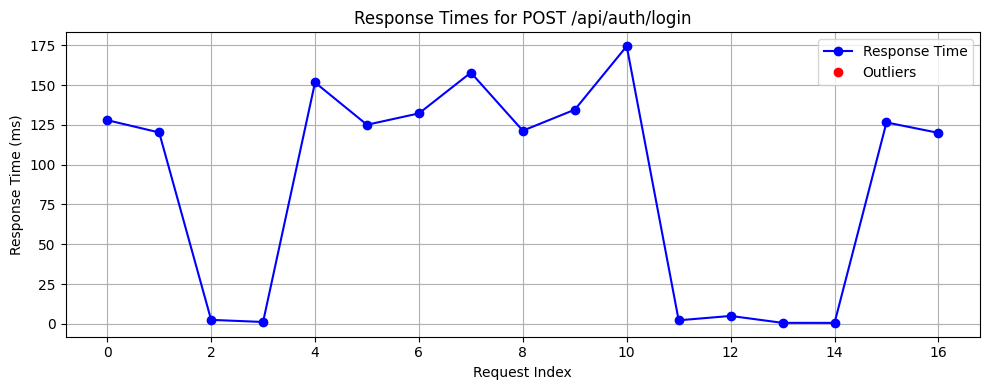

Endpoint: POST /api/auth/login
  Count: 17
  OldMean: 88.452 ms
  RobustMean: 88.452 ms
  Median: 121.319 ms
  95th Percentile: 161.101 ms
  Max: 174.383 ms, Min: 0.643 ms
  Statuses: ['200', '200', '401', '401', '200', '200', '200', '200', '200', '200', '200', '401', '401', '401', '401', '200', '200']
--------------------------------------------------


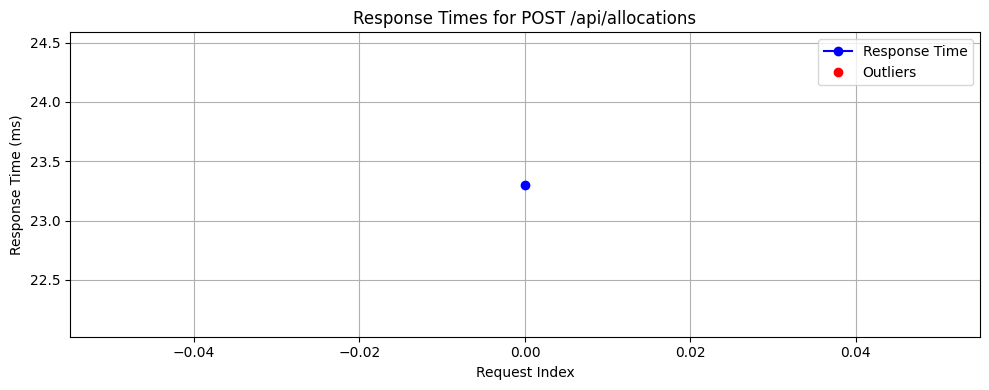

Endpoint: POST /api/allocations
  Count: 1
  OldMean: 23.304 ms
  RobustMean: 23.304 ms
  Median: 23.304 ms
  95th Percentile: 23.304 ms
  Max: 23.304 ms, Min: 23.304 ms
  Statuses: ['500']
--------------------------------------------------


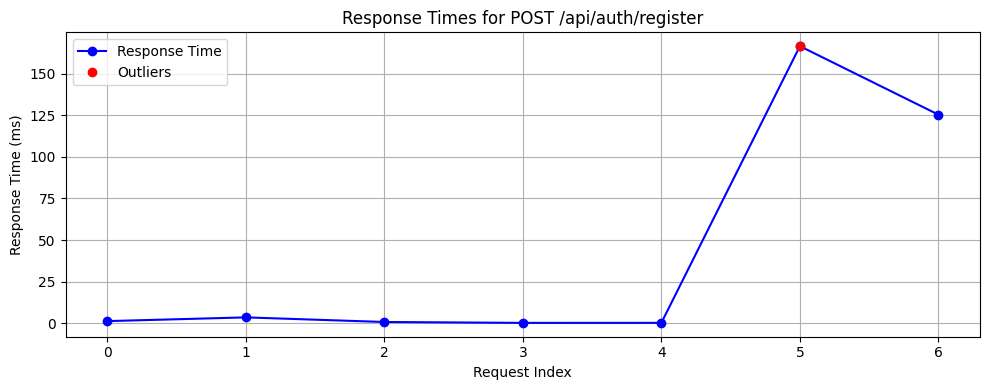

Endpoint: POST /api/auth/register
  Count: 7
  OldMean: 42.520 ms
  RobustMean: 21.838 ms
  Median: 1.202 ms
  95th Percentile: 154.247 ms
  Max: 166.611 ms, Min: 0.140 ms
  Statuses: ['401', '401', '401', '401', '401', '201', '201']
--------------------------------------------------


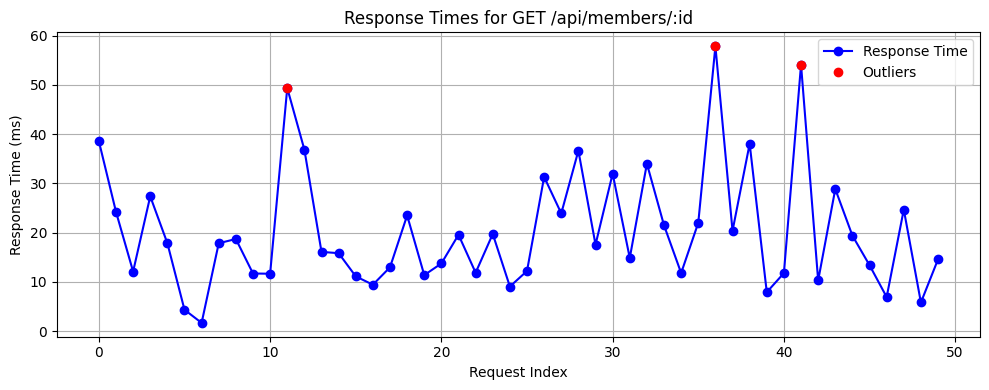

Endpoint: GET /api/members/:id
  Count: 50
  OldMean: 20.367 ms
  RobustMean: 18.236 ms
  Median: 17.709 ms
  95th Percentile: 44.494 ms
  Max: 57.846 ms, Min: 1.686 ms
  Statuses: ['304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '200', '404', '404', '200', '304', '200', '304', '304', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '200', '304', '200', '304']
--------------------------------------------------


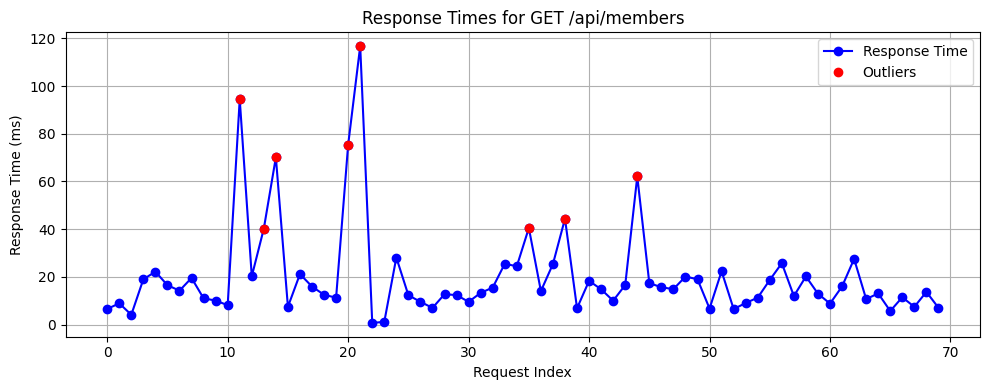

Endpoint: GET /api/members
  Count: 70
  OldMean: 20.055 ms
  RobustMean: 13.871 ms
  Median: 14.119 ms
  95th Percentile: 66.507 ms
  Max: 116.733 ms, Min: 0.694 ms
  Statuses: ['304', '304', '304', '304', '304', '304', '304', '304', '304', '200', '200', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '401', '401', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '304', '304', '200', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '200', '304', '200', '200', '304', '200', '200', '304', '200', '200', '200', '200', '304', '304', '200']
--------------------------------------------------


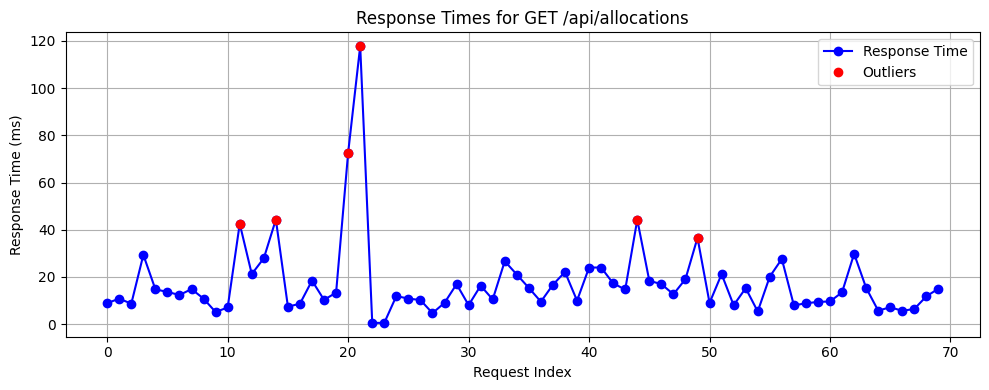

Endpoint: GET /api/allocations
  Count: 70
  OldMean: 17.473 ms
  RobustMean: 13.515 ms
  Median: 13.430 ms
  95th Percentile: 43.484 ms
  Max: 117.779 ms, Min: 0.546 ms
  Statuses: ['304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '401', '401', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304']
--------------------------------------------------


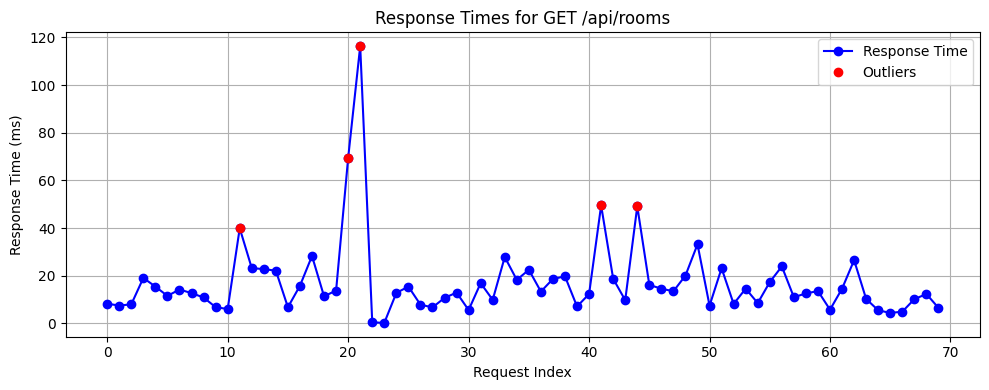

Endpoint: GET /api/rooms
  Count: 70
  OldMean: 17.069 ms
  RobustMean: 13.395 ms
  Median: 13.139 ms
  95th Percentile: 44.975 ms
  Max: 116.304 ms, Min: 0.213 ms
  Statuses: ['304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '401', '401', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304']
--------------------------------------------------


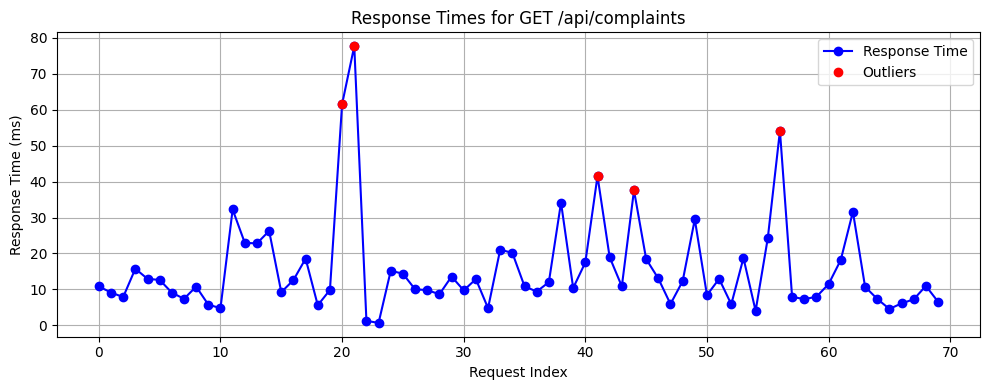

Endpoint: GET /api/complaints
  Count: 70
  OldMean: 15.687 ms
  RobustMean: 12.705 ms
  Median: 10.939 ms
  95th Percentile: 39.729 ms
  Max: 77.624 ms, Min: 0.715 ms
  Statuses: ['304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '401', '401', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304']
--------------------------------------------------


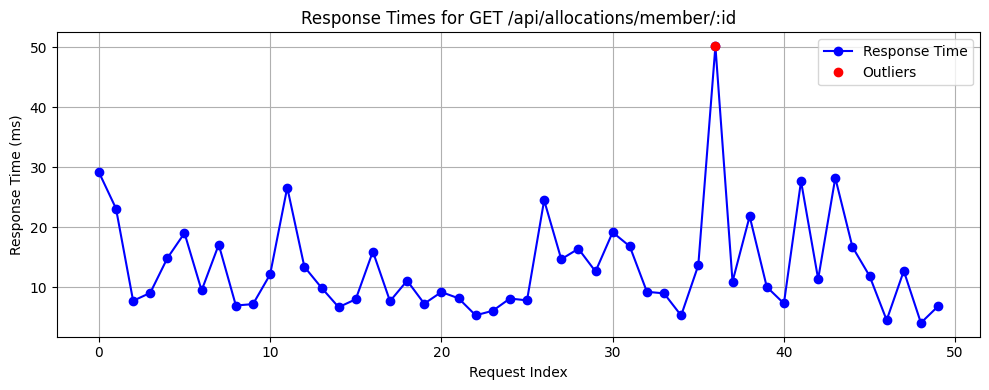

Endpoint: GET /api/allocations/member/:id
  Count: 50
  OldMean: 13.423 ms
  RobustMean: 12.672 ms
  Median: 10.979 ms
  95th Percentile: 27.971 ms
  Max: 50.209 ms, Min: 4.010 ms
  Statuses: ['304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '200', '304', '200', '304', '304', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '200', '304', '200', '304']
--------------------------------------------------


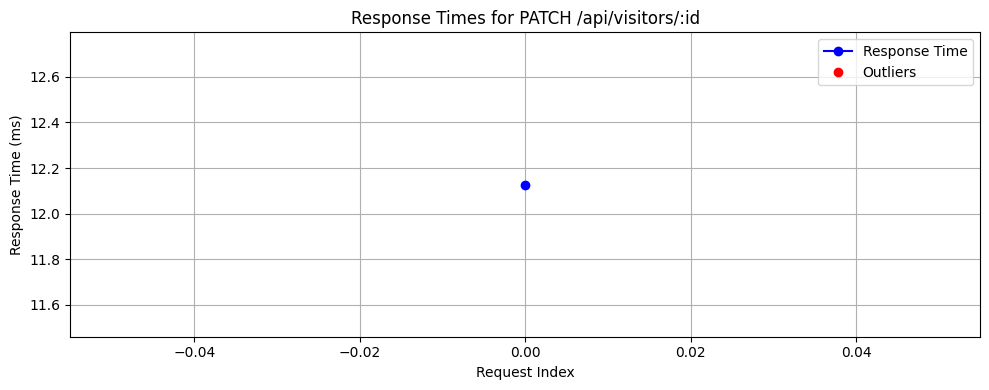

Endpoint: PATCH /api/visitors/:id
  Count: 1
  OldMean: 12.128 ms
  RobustMean: 12.128 ms
  Median: 12.128 ms
  95th Percentile: 12.128 ms
  Max: 12.128 ms, Min: 12.128 ms
  Statuses: ['200']
--------------------------------------------------


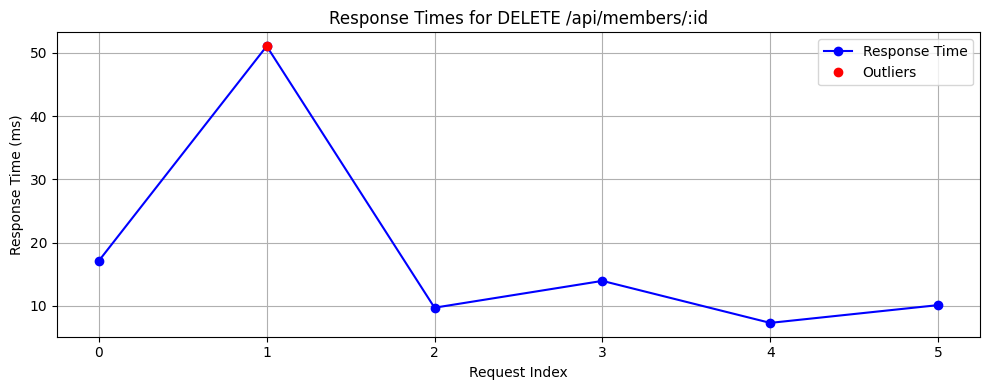

Endpoint: DELETE /api/members/:id
  Count: 6
  OldMean: 18.226 ms
  RobustMean: 11.657 ms
  Median: 12.049 ms
  95th Percentile: 42.589 ms
  Max: 51.072 ms, Min: 7.324 ms
  Statuses: ['200', '200', '200', '200', '200', '200']
--------------------------------------------------


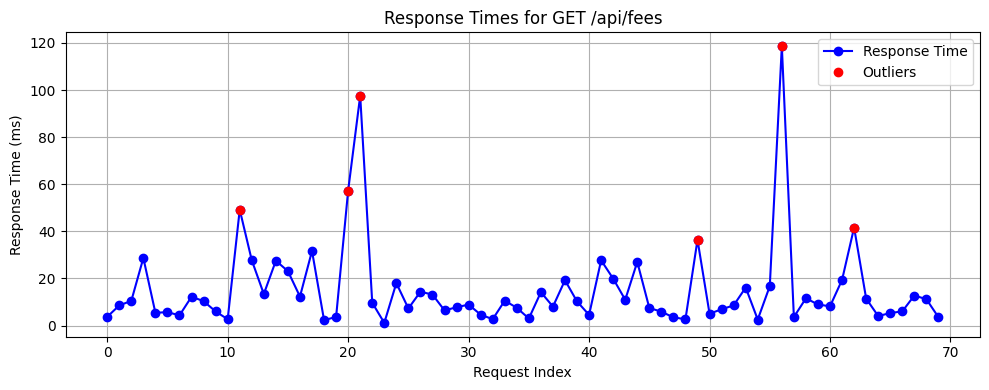

Endpoint: GET /api/fees
  Count: 70
  OldMean: 15.398 ms
  RobustMean: 10.580 ms
  Median: 9.297 ms
  95th Percentile: 45.774 ms
  Max: 118.642 ms, Min: 1.115 ms
  Statuses: ['304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '401', '401', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304']
--------------------------------------------------


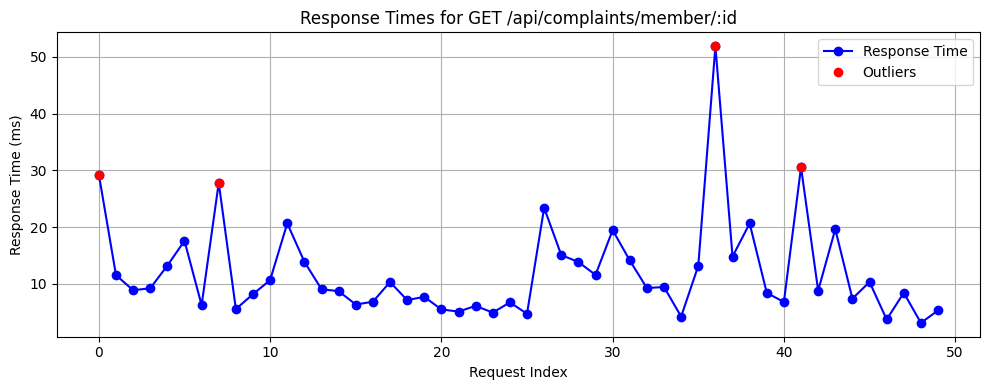

Endpoint: GET /api/complaints/member/:id
  Count: 50
  OldMean: 12.117 ms
  RobustMean: 10.138 ms
  Median: 9.146 ms
  95th Percentile: 28.612 ms
  Max: 51.897 ms, Min: 3.129 ms
  Statuses: ['304', '304', '304', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '200', '304', '200', '304', '304', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '200', '304', '200', '304']
--------------------------------------------------


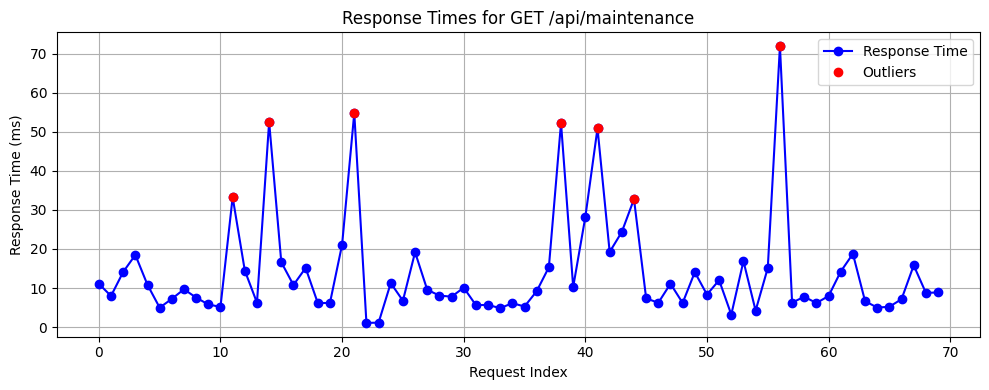

Endpoint: GET /api/maintenance
  Count: 70
  OldMean: 14.003 ms
  RobustMean: 10.027 ms
  Median: 9.024 ms
  95th Percentile: 51.651 ms
  Max: 71.950 ms, Min: 1.070 ms
  Statuses: ['304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '401', '401', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304']
--------------------------------------------------


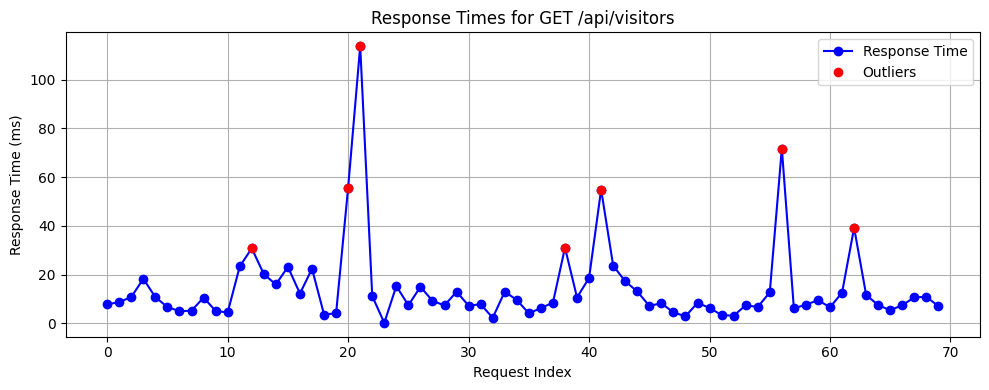

Endpoint: GET /api/visitors
  Count: 70
  OldMean: 14.470 ms
  RobustMean: 9.773 ms
  Median: 9.023 ms
  95th Percentile: 47.863 ms
  Max: 113.679 ms, Min: 0.239 ms
  Statuses: ['200', '304', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '401', '401', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304']
--------------------------------------------------


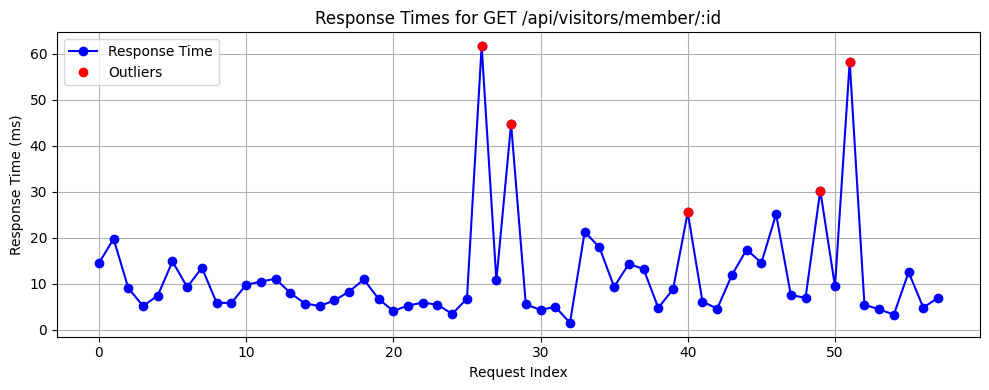

Endpoint: GET /api/visitors/member/:id
  Count: 58
  OldMean: 11.987 ms
  RobustMean: 8.962 ms
  Median: 8.122 ms
  95th Percentile: 32.413 ms
  Max: 61.608 ms, Min: 1.471 ms
  Statuses: ['304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '304', '304', '401', '401', '304', '200', '304', '200', '403', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '200', '304', '200', '304']
--------------------------------------------------


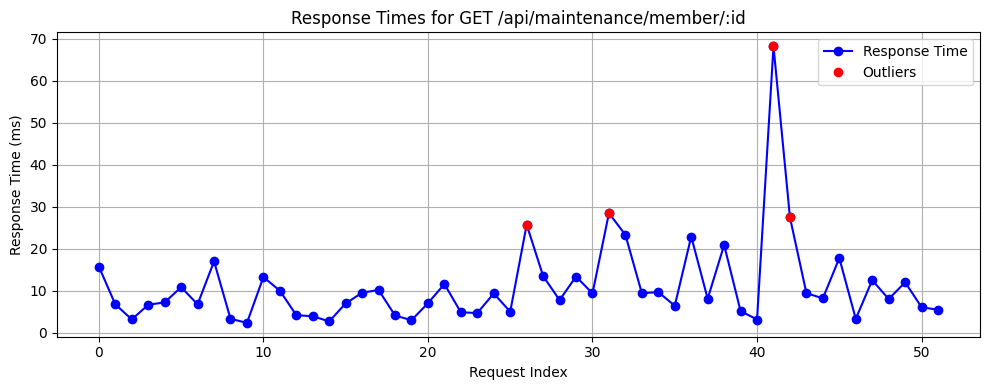

Endpoint: GET /api/maintenance/member/:id
  Count: 52
  OldMean: 11.115 ms
  RobustMean: 8.915 ms
  Median: 8.180 ms
  95th Percentile: 26.555 ms
  Max: 68.277 ms, Min: 2.383 ms
  Statuses: ['304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '200', '304', '200', '304', '304', '304', '304', '304', '200', '304', '304', '304', '403', '304', '304', '304', '304', '200', '304', '200', '304']
--------------------------------------------------


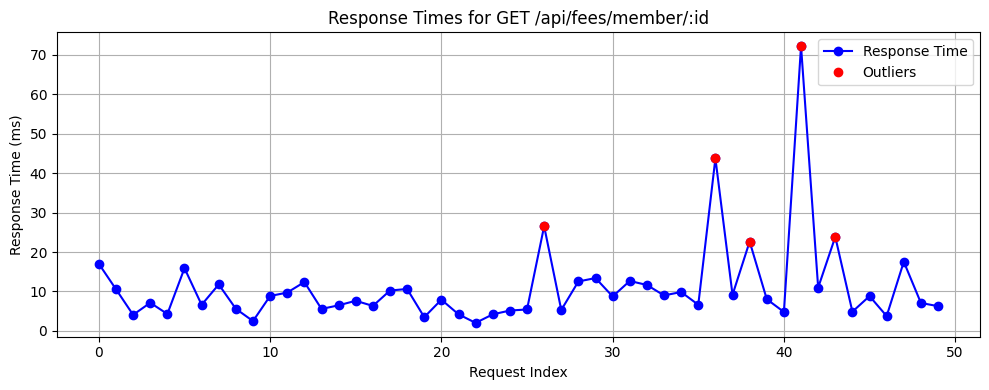

Endpoint: GET /api/fees/member/:id
  Count: 50
  OldMean: 11.119 ms
  RobustMean: 8.157 ms
  Median: 8.393 ms
  95th Percentile: 25.320 ms
  Max: 72.149 ms, Min: 2.043 ms
  Statuses: ['304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '200', '304', '304', '304', '304', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '200', '304', '200', '304']
--------------------------------------------------


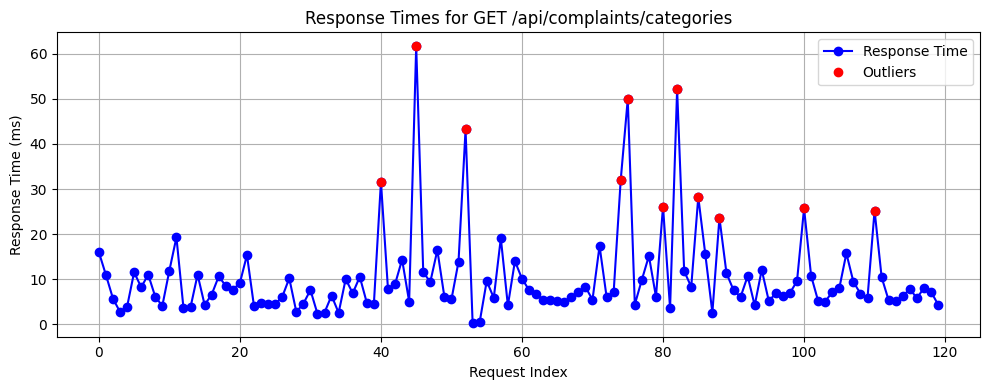

Endpoint: GET /api/complaints/categories
  Count: 120
  OldMean: 10.388 ms
  RobustMean: 7.771 ms
  Median: 7.234 ms
  95th Percentile: 28.408 ms
  Max: 61.691 ms, Min: 0.335 ms
  Statuses: ['304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '401', '401', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '200', '200', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304

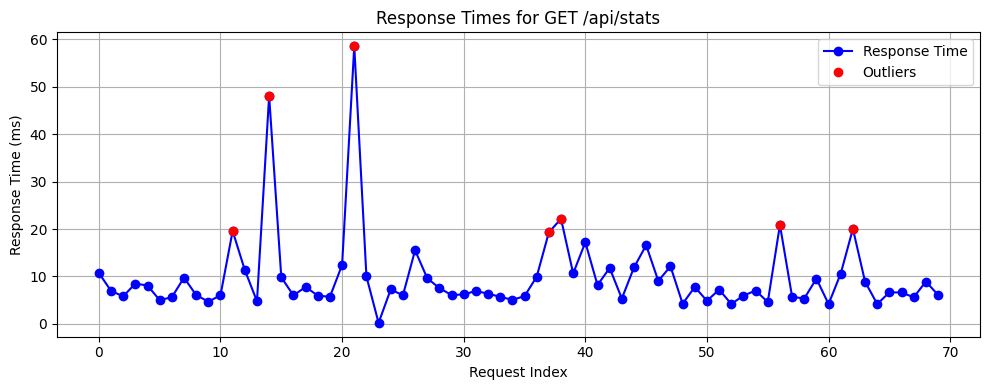

Endpoint: GET /api/stats
  Count: 70
  OldMean: 9.848 ms
  RobustMean: 7.633 ms
  Median: 7.133 ms
  95th Percentile: 20.489 ms
  Max: 58.534 ms, Min: 0.219 ms
  Statuses: ['304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '200', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '401', '401', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '304', '304', '200', '304', '304', '200', '304', '304', '304', '304', '304', '304', '200', '304', '200', '200', '304', '200', '304', '200', '200', '304', '200', '200', '304', '200', '200', '200', '200', '304', '304', '200']
--------------------------------------------------


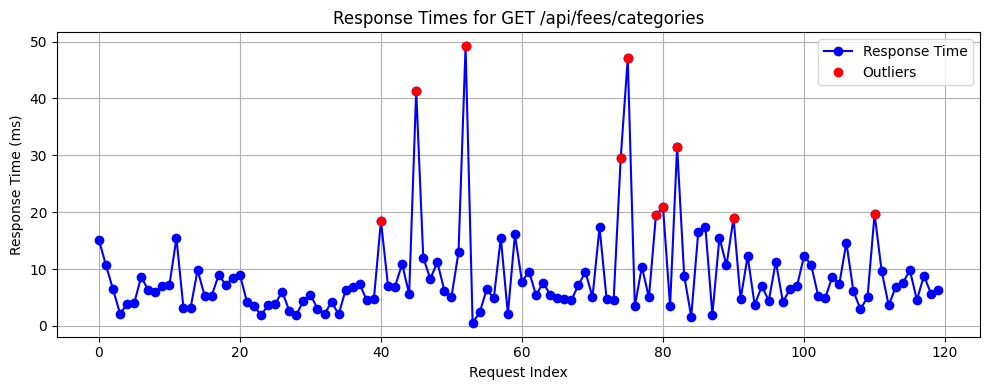

Endpoint: GET /api/fees/categories
  Count: 120
  OldMean: 8.818 ms
  RobustMean: 6.927 ms
  Median: 6.444 ms
  95th Percentile: 19.749 ms
  Max: 49.198 ms, Min: 0.540 ms
  Statuses: ['304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '401', '401', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304

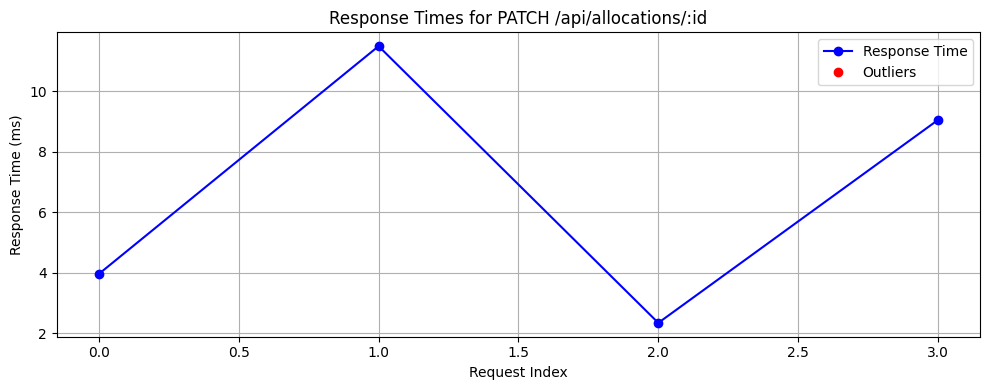

Endpoint: PATCH /api/allocations/:id
  Count: 4
  OldMean: 6.714 ms
  RobustMean: 6.714 ms
  Median: 6.509 ms
  95th Percentile: 11.122 ms
  Max: 11.487 ms, Min: 2.350 ms
  Statuses: ['500', '200', '500', '200']
--------------------------------------------------


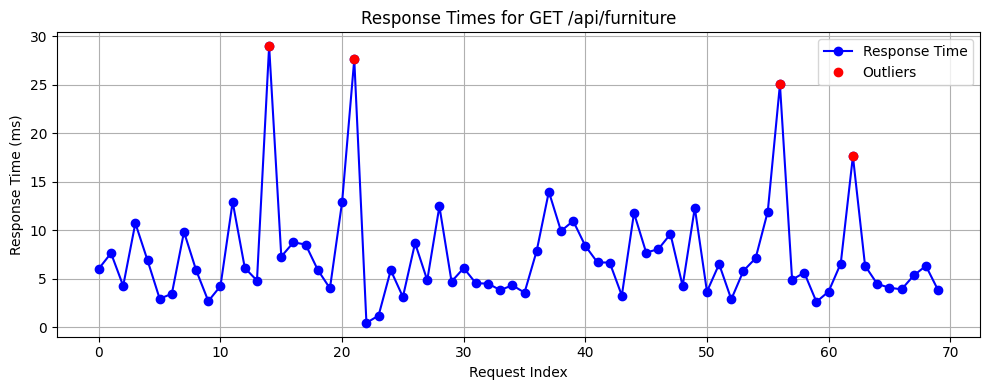

Endpoint: GET /api/furniture
  Count: 70
  OldMean: 7.420 ms
  RobustMean: 6.366 ms
  Median: 6.059 ms
  95th Percentile: 15.976 ms
  Max: 28.976 ms, Min: 0.431 ms
  Statuses: ['304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '401', '401', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304']
--------------------------------------------------


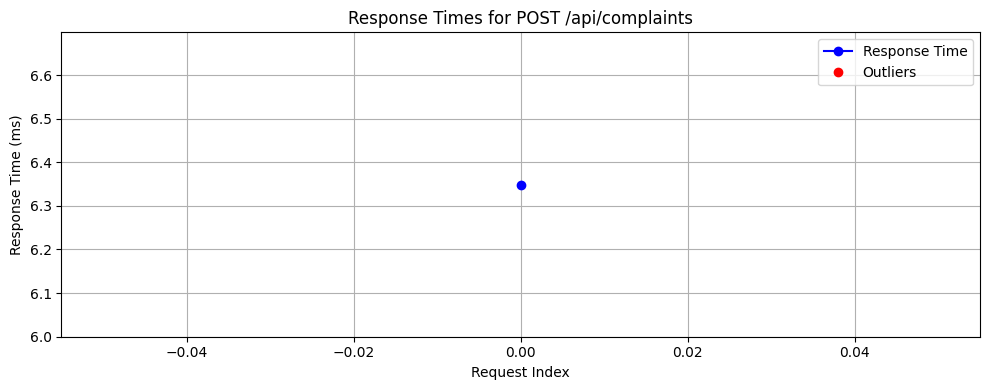

Endpoint: POST /api/complaints
  Count: 1
  OldMean: 6.349 ms
  RobustMean: 6.349 ms
  Median: 6.349 ms
  95th Percentile: 6.349 ms
  Max: 6.349 ms, Min: 6.349 ms
  Statuses: ['201']
--------------------------------------------------


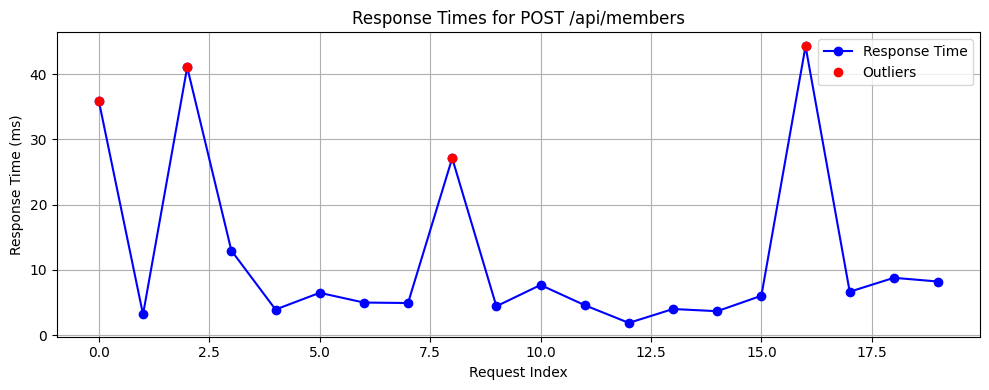

Endpoint: POST /api/members
  Count: 20
  OldMean: 12.040 ms
  RobustMean: 5.781 ms
  Median: 6.267 ms
  95th Percentile: 41.208 ms
  Max: 44.273 ms, Min: 1.885 ms
  Statuses: ['201', '400', '400', '500', '500', '500', '500', '500', '201', '400', '201', '400', '400', '201', '400', '201', '201', '400', '400', '201']
--------------------------------------------------


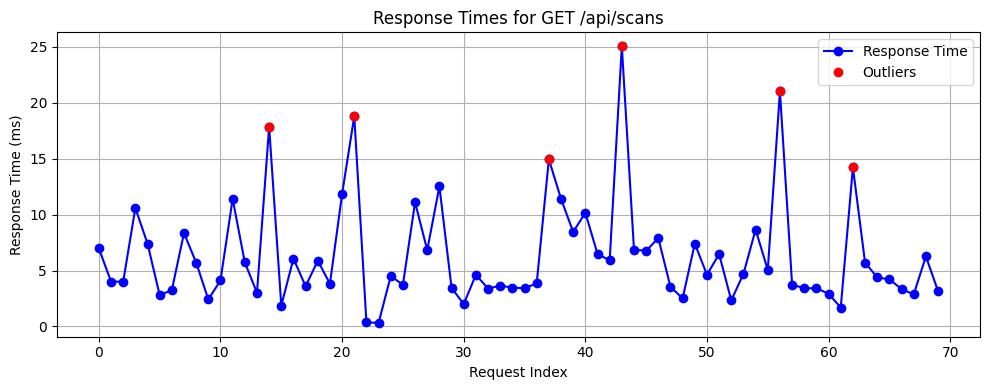

Endpoint: GET /api/scans
  Count: 70
  OldMean: 6.374 ms
  RobustMean: 5.224 ms
  Median: 4.620 ms
  95th Percentile: 16.540 ms
  Max: 25.063 ms, Min: 0.316 ms
  Statuses: ['304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '401', '401', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '200', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304']
--------------------------------------------------


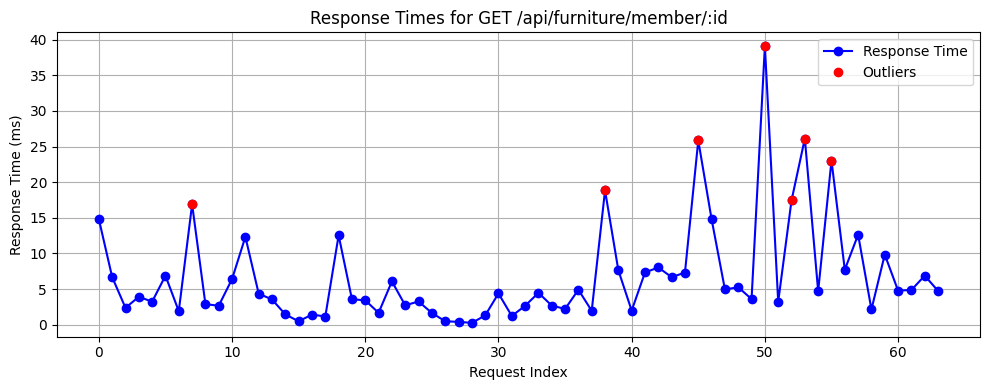

Endpoint: GET /api/furniture/member/:id
  Count: 64
  OldMean: 6.801 ms
  RobustMean: 4.702 ms
  Median: 4.439 ms
  95th Percentile: 22.405 ms
  Max: 39.072 ms, Min: 0.269 ms
  Statuses: ['304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '304', '401', '401', '401', '401', '304', '304', '304', '401', '304', '304', '304', '401', '401', '401', '401', '401', '304', '401', '401', '304', '304', '304', '304', '304', '304', '304', '401', '401', '304', '200', '304', '200', '304', '200', '304', '304', '304', '304', '304', '200', '304', '304', '304', '304', '304', '304', '200', '304', '200', '304']
--------------------------------------------------


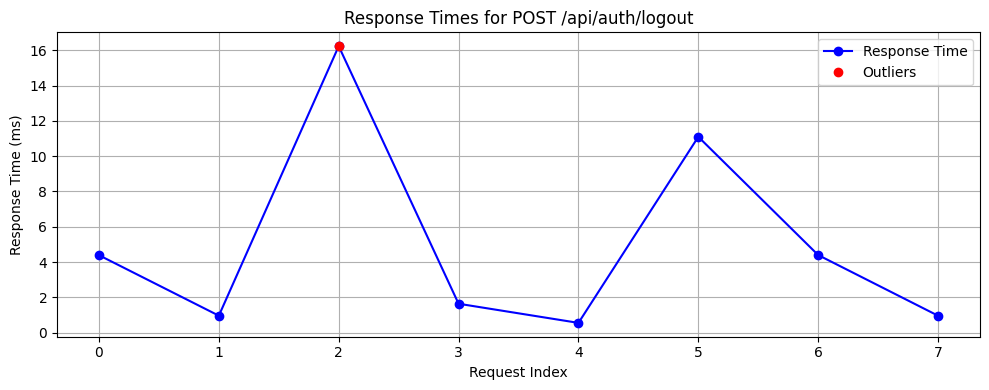

Endpoint: POST /api/auth/logout
  Count: 8
  OldMean: 5.026 ms
  RobustMean: 3.425 ms
  Median: 3.010 ms
  95th Percentile: 14.434 ms
  Max: 16.232 ms, Min: 0.550 ms
  Statuses: ['200', '200', '200', '200', '200', '200', '200', '200']
--------------------------------------------------


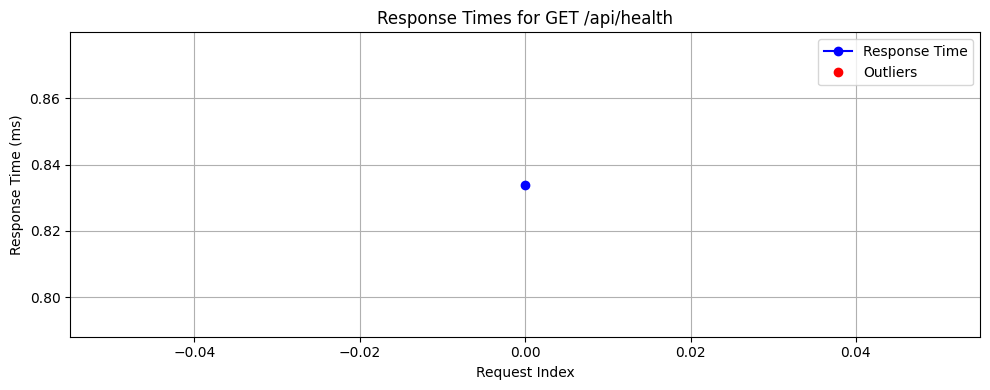

Endpoint: GET /api/health
  Count: 1
  OldMean: 0.834 ms
  RobustMean: 0.834 ms
  Median: 0.834 ms
  95th Percentile: 0.834 ms
  Max: 0.834 ms, Min: 0.834 ms
  Statuses: ['200']
--------------------------------------------------


In [ ]:
# Plot all APIs
plot_api_times(df_sorted)

#Performance Comparison of API Logs (Before vs After)

This script compares the performance of API endpoints between two log files: Before.log and After.log.

First, the process_log() function reads a log file, extracts the HTTP method, API endpoint, and response time, and groups requests by endpoint. Numeric IDs in endpoints are normalized so similar requests are analyzed together. For each endpoint, the script computes key performance metrics such as mean response time, robust mean (after removing outliers using the IQR method), median, and 95th percentile latency.

Next, the results from the before and after logs are merged based on the API endpoint. The code then calculates the percentage improvement for each metric to evaluate performance changes after optimization.

The final comparison is sorted by robust mean improvement, printed to the console, and saved to benchmark_comparison.csv.

An optional plotting function generates bar charts comparing the robust mean response time before and after optimization for each API endpoint, helping visually assess performance improvements.

In [ ]:
# Process a log file
def process_log(log_file_path):
    api_data = {}

    with open(log_file_path, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                method = match.group(1)
                endpoint = match.group(2)
                response_time = float(match.group(4))

                if not endpoint.startswith("/api/"):
                    continue

                endpoint_norm = normalize_endpoint(endpoint)
                key = f"{method} {endpoint_norm}"

                api_data.setdefault(key, []).append(response_time)

    data = []
    for key, times in api_data.items():
        times_array = np.array(times)

        q1, q3 = np.percentile(times_array, [25, 75])
        iqr = q3 - q1

        filtered_times = times_array[
            (times_array >= q1 - 1.5 * iqr) &
            (times_array <= q3 + 1.5 * iqr)
        ]

        data.append({
            "MethodEndpoint": key,
            "Count": len(times),
            "Mean": times_array.mean(),
            "RobustMean": filtered_times.mean() if len(filtered_times) > 0 else np.nan,
            "Median": np.median(times_array),
            "P95": np.percentile(times_array, 95),
        })

    return pd.DataFrame(data)

In [ ]:
# Load both logs
df_before = process_log("Before.log")
df_after = process_log("After.log")

In [ ]:
# Merge on API endpoint
df_compare = pd.merge(
    df_before,
    df_after,
    on="MethodEndpoint",
    suffixes=("_Before", "_After")
)

In [ ]:
# Compute improvements (%)
df_compare["Mean_Improvement_%"] = (
    (df_compare["Mean_Before"] - df_compare["Mean_After"]) /
    df_compare["Mean_Before"]
) * 100

df_compare["RobustMean_Improvement_%"] = (
    (df_compare["RobustMean_Before"] - df_compare["RobustMean_After"]) /
    df_compare["RobustMean_Before"]
) * 100

df_compare["Median_Improvement_%"] = (
    (df_compare["Median_Before"] - df_compare["Median_After"]) /
    df_compare["Median_Before"]
) * 100

df_compare["P95_Improvement_%"] = (
    (df_compare["P95_Before"] - df_compare["P95_After"]) /
    df_compare["P95_Before"]
) * 100

In [ ]:
# Sort by best improvement
df_compare_sorted = df_compare.sort_values(
    by="RobustMean_Improvement_%",
    ascending=False
)

In [ ]:
# Print results
print("\n=== PERFORMANCE COMPARISON (Before vs After) ===\n")
print(df_compare_sorted[[
    "MethodEndpoint",
    "Count_Before", "Count_After",
    "Mean_Before", "Mean_After", "Mean_Improvement_%",
    "RobustMean_Before", "RobustMean_After", "RobustMean_Improvement_%",
    "Median_Before", "Median_After", "Median_Improvement_%",
    "P95_Before", "P95_After", "P95_Improvement_%"
]])


=== PERFORMANCE COMPARISON (Before vs After) ===

                     MethodEndpoint  Count_Before  Count_After  Mean_Before  \
29            POST /api/auth/logout             1           12     2.621000   
2                     GET /api/fees            22          110    12.232045   
28      POST /api/scans/maintenance             1            4     8.960000   
25  GET /api/maintenance/member/:id             6           12     8.760333   
4                 GET /api/visitors            22          110    13.297727   
12             GET /api/rooms/types            22          110     4.574227   
27             POST /api/scans/gate             2            5     6.104000   
13                 GET /api/hostels            22          110     5.095682   
8                GET /api/furniture            22          110     8.843864   
3               GET /api/complaints            22          110    15.060727   
11             GET /api/maintenance            22          110    11.042955   
1

In [ ]:
# Save to CSV
df_compare_sorted.to_csv("benchmark_comparison.csv", index=False)

print("\nResults saved to benchmark_comparison.csv")


Results saved to benchmark_comparison.csv


In [ ]:
import matplotlib.pyplot as plt
import math

def plot_comparison_matrix(df, cols=3):
    n = len(df)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
    axes = axes.flatten()  # make indexing easier

    for i, (_, row) in enumerate(df.iterrows()):
        labels = ["Before", "After"]
        values = [row["RobustMean_Before"], row["RobustMean_After"]]

        axes[i].bar(labels, values, color=['red', 'green'])
        axes[i].set_title(row["MethodEndpoint"])
        axes[i].set_ylabel("Robust Mean Response Time (ms)")
        axes[i].grid(axis='y')

    # Remove unused subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

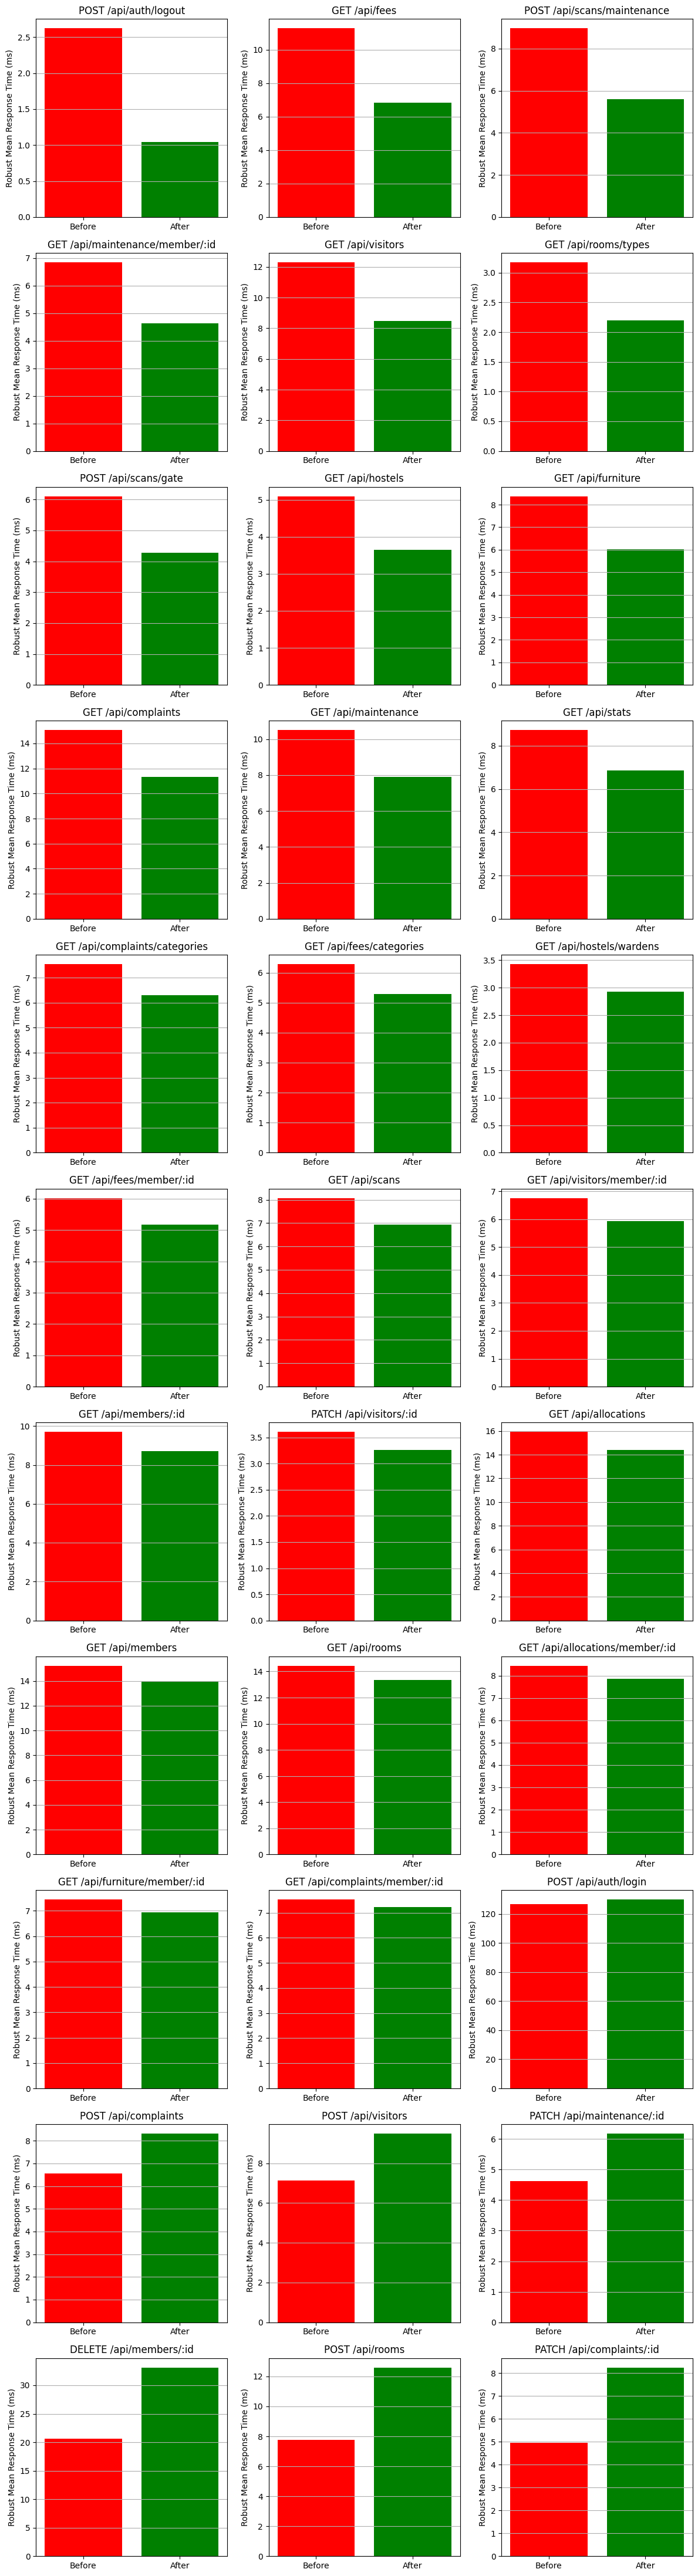

In [ ]:
# Uncomment if you want plots
plot_comparison_matrix(df_compare_sorted, cols=3)

#Visual Comparison of API Performance (Before vs After)

This section compares the robust mean response time of API endpoints between the Before.log and After.log datasets. The results from both logs are merged by endpoint, and the percentage improvement in robust mean response time is calculated. The endpoints are then sorted based on the highest performance improvement.

The plot_comparison_lines() function visualizes the response times for each API by plotting Before and After request latencies on the same graph. Outliers are detected using the IQR method and highlighted separately for both datasets.

These plots help visually analyze how the response time distribution changed after optimization, making it easier to identify performance improvements or anomalies.

In [ ]:
def process_log(log_file_path):
    api_data = {}

    with open(log_file_path, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                method = match.group(1)
                endpoint = match.group(2)
                response_time = float(match.group(4))

                if not endpoint.startswith("/api/"):
                    continue

                endpoint_norm = normalize_endpoint(endpoint)
                key = f"{method} {endpoint_norm}"

                api_data.setdefault(key, []).append(response_time)

    data = []
    for key, times in api_data.items():
        times_array = np.array(times)

        q1, q3 = np.percentile(times_array, [25, 75])
        iqr = q3 - q1
        filtered = times_array[
            (times_array >= q1 - 1.5 * iqr) &
            (times_array <= q3 + 1.5 * iqr)
        ]

        data.append({
            "MethodEndpoint": key,
            "Count": len(times),
            "Mean": times_array.mean(),
            "RobustMean": filtered.mean() if len(filtered) > 0 else np.nan,
            "Median": np.median(times_array),
            "P95": np.percentile(times_array, 95),
            "AllTimes": times_array
        })

    return pd.DataFrame(data)

In [ ]:
# Load logs
df_before = process_log("Before.log")
df_after = process_log("After.log")

In [ ]:
# Merge
df_compare = pd.merge(
    df_before,
    df_after,
    on="MethodEndpoint",
    suffixes=("_Before", "_After")
)

In [ ]:
# Improvements
df_compare["RobustMean_Improvement_%"] = (
    (df_compare["RobustMean_Before"] - df_compare["RobustMean_After"]) /
    df_compare["RobustMean_Before"]
) * 100

In [ ]:
df_compare_sorted = df_compare.sort_values(
    by="RobustMean_Improvement_%",
    ascending=False
)

In [ ]:
print("\n=== PERFORMANCE COMPARISON (Before vs After) ===\n")
print(df_compare_sorted[[
    "MethodEndpoint",
    "RobustMean_Before",
    "RobustMean_After",
    "RobustMean_Improvement_%"
]])


=== PERFORMANCE COMPARISON (Before vs After) ===

                     MethodEndpoint  RobustMean_Before  RobustMean_After  \
29            POST /api/auth/logout           2.621000          1.044273   
2                     GET /api/fees          11.272762          6.828870   
28      POST /api/scans/maintenance           8.960000          5.598000   
25  GET /api/maintenance/member/:id           6.848000          4.637167   
4                 GET /api/visitors          12.297524          8.476349   
12             GET /api/rooms/types           3.174632          2.201647   
27             POST /api/scans/gate           6.104000          4.266800   
13                 GET /api/hostels           5.095682          3.651886   
8                GET /api/furniture           8.373667          6.016313   
3               GET /api/complaints          15.060727         11.311519   
11             GET /api/maintenance          10.500333          7.903562   
10                   GET /api/stats  

In [ ]:
# ✅ GRAPH FUNCTION (KEY PART)
def plot_comparison_lines(df):
    for _, row in df.iterrows():
        before = row["AllTimes_Before"]
        after = row["AllTimes_After"]
        key = row["MethodEndpoint"]

        # Outliers detection (Before)
        q1_b, q3_b = np.percentile(before, [25, 75])
        iqr_b = q3_b - q1_b
        outliers_b = (before < q1_b - 1.5 * iqr_b) | (before > q3_b + 1.5 * iqr_b)

        # Outliers detection (After)
        q1_a, q3_a = np.percentile(after, [25, 75])
        iqr_a = q3_a - q1_a
        outliers_a = (after < q1_a - 1.5 * iqr_a) | (after > q3_a + 1.5 * iqr_a)

        plt.figure(figsize=(12, 5))

        # BEFORE (blue)
        plt.plot(before, 'b-o', label='Before')

        # AFTER (green)
        plt.plot(after, 'g-o', label='After')

        # OUTLIERS
        plt.plot(np.where(outliers_b)[0], before[outliers_b], 'ro', label='Before Outliers')
        plt.plot(np.where(outliers_a)[0], after[outliers_a], 'mo', label='After Outliers')

        plt.title(f"{key}")
        plt.xlabel("Request Index")
        plt.ylabel("Response Time (ms)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # Print summary
        print(f"\nEndpoint: {key}")
        print(f"Before Robust Mean: {row['RobustMean_Before']:.3f} ms")
        print(f"After Robust Mean:  {row['RobustMean_After']:.3f} ms")
        print(f"Improvement:        {row['RobustMean_Improvement_%']:.2f}%")
        print("-" * 50)

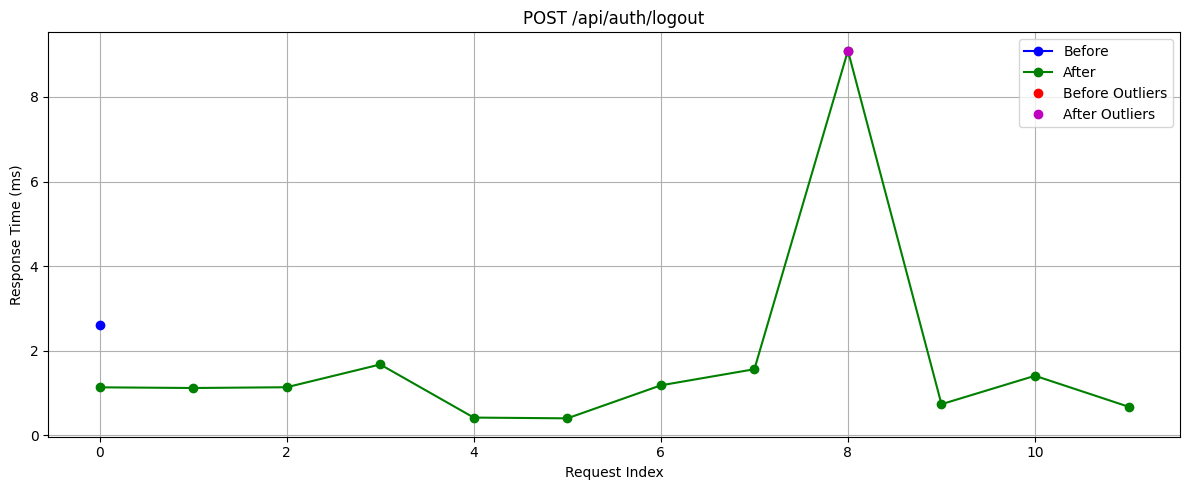


Endpoint: POST /api/auth/logout
Before Robust Mean: 2.621 ms
After Robust Mean:  1.044 ms
Improvement:        60.16%
--------------------------------------------------


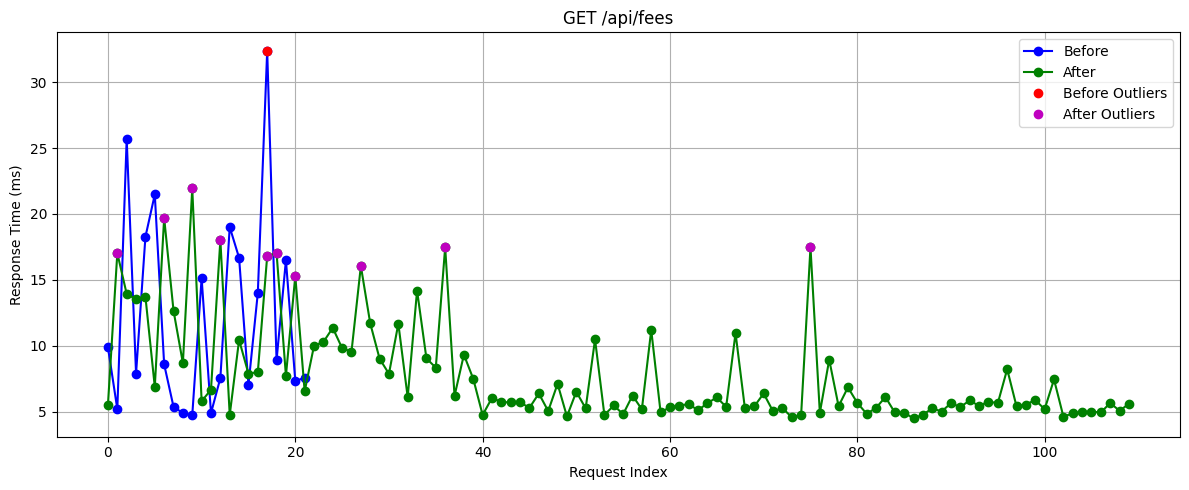


Endpoint: GET /api/fees
Before Robust Mean: 11.273 ms
After Robust Mean:  6.829 ms
Improvement:        39.42%
--------------------------------------------------


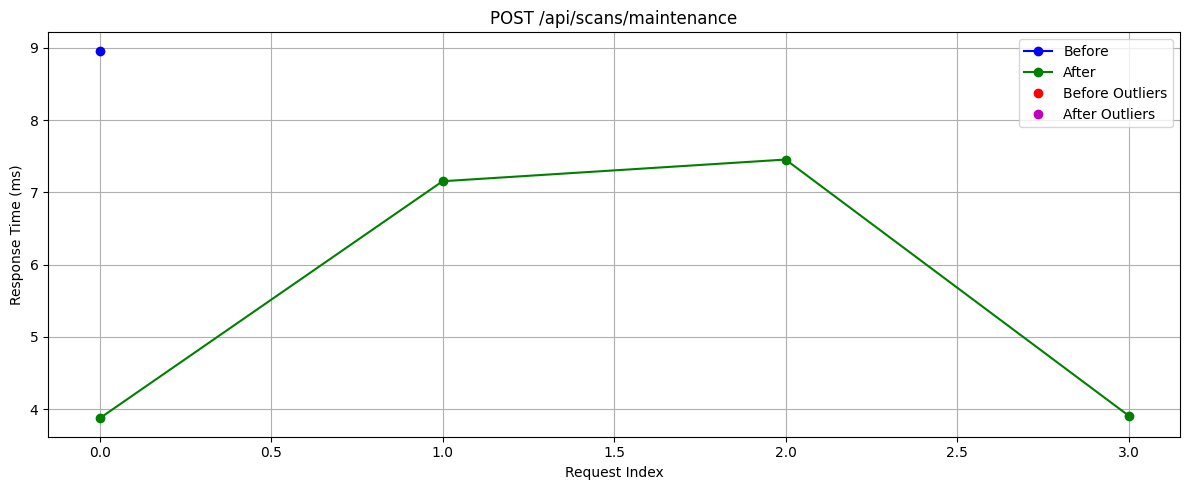


Endpoint: POST /api/scans/maintenance
Before Robust Mean: 8.960 ms
After Robust Mean:  5.598 ms
Improvement:        37.52%
--------------------------------------------------


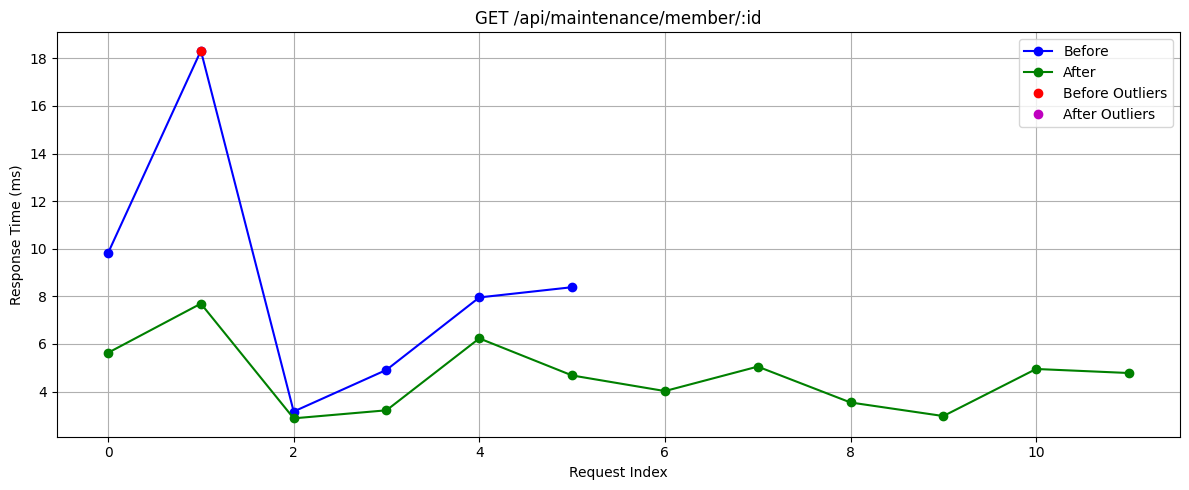


Endpoint: GET /api/maintenance/member/:id
Before Robust Mean: 6.848 ms
After Robust Mean:  4.637 ms
Improvement:        32.28%
--------------------------------------------------


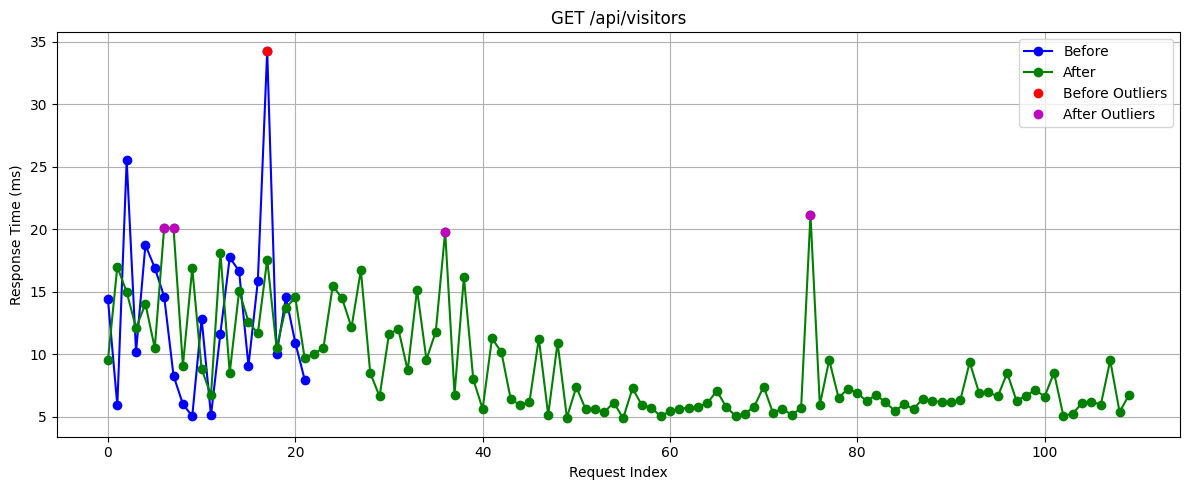


Endpoint: GET /api/visitors
Before Robust Mean: 12.298 ms
After Robust Mean:  8.476 ms
Improvement:        31.07%
--------------------------------------------------


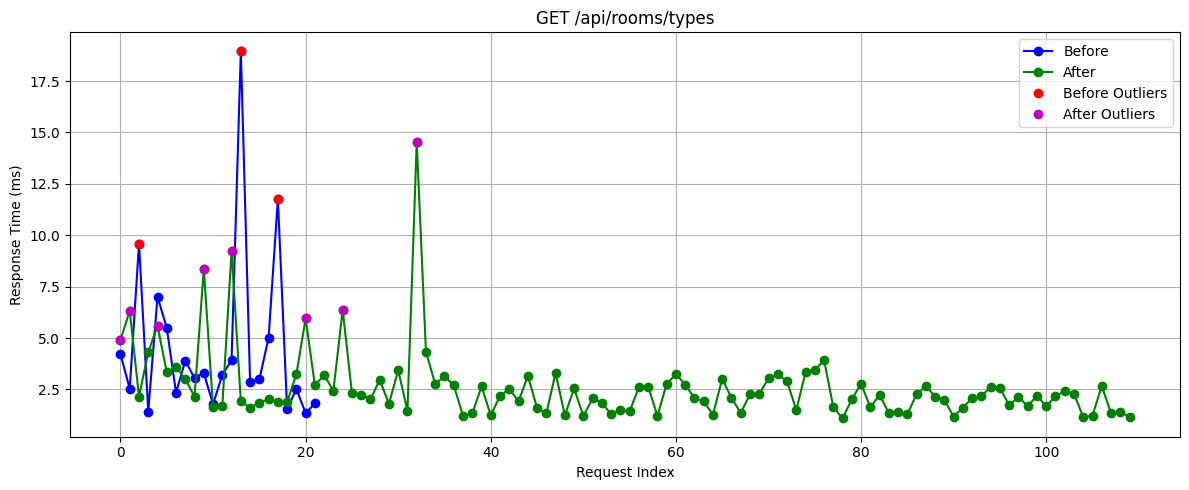


Endpoint: GET /api/rooms/types
Before Robust Mean: 3.175 ms
After Robust Mean:  2.202 ms
Improvement:        30.65%
--------------------------------------------------


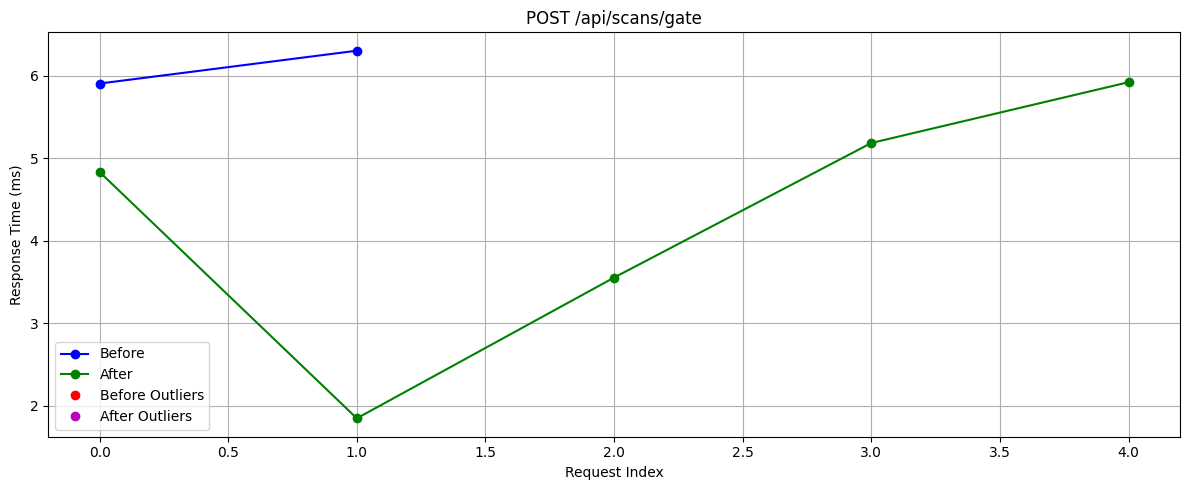


Endpoint: POST /api/scans/gate
Before Robust Mean: 6.104 ms
After Robust Mean:  4.267 ms
Improvement:        30.10%
--------------------------------------------------


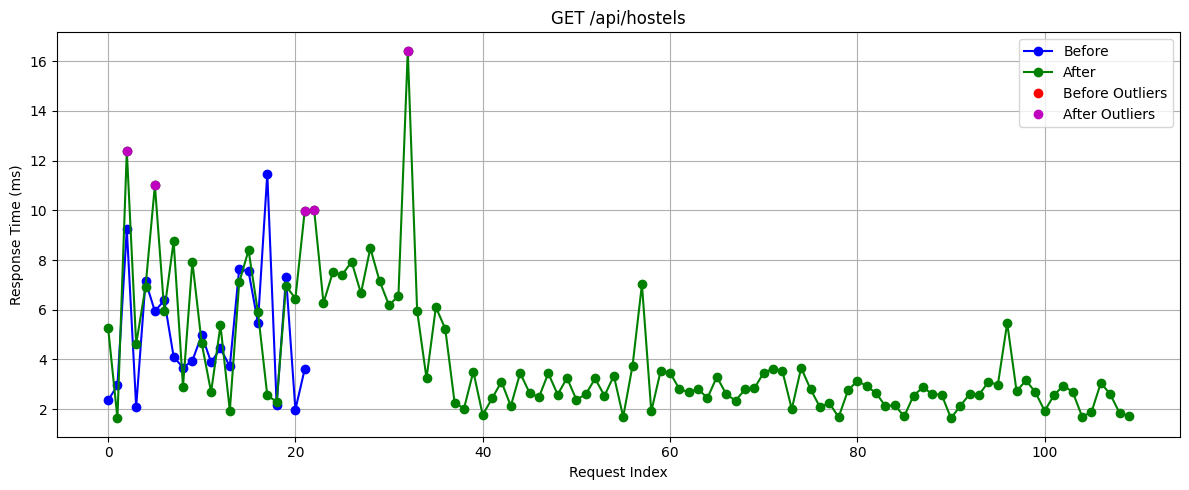


Endpoint: GET /api/hostels
Before Robust Mean: 5.096 ms
After Robust Mean:  3.652 ms
Improvement:        28.33%
--------------------------------------------------


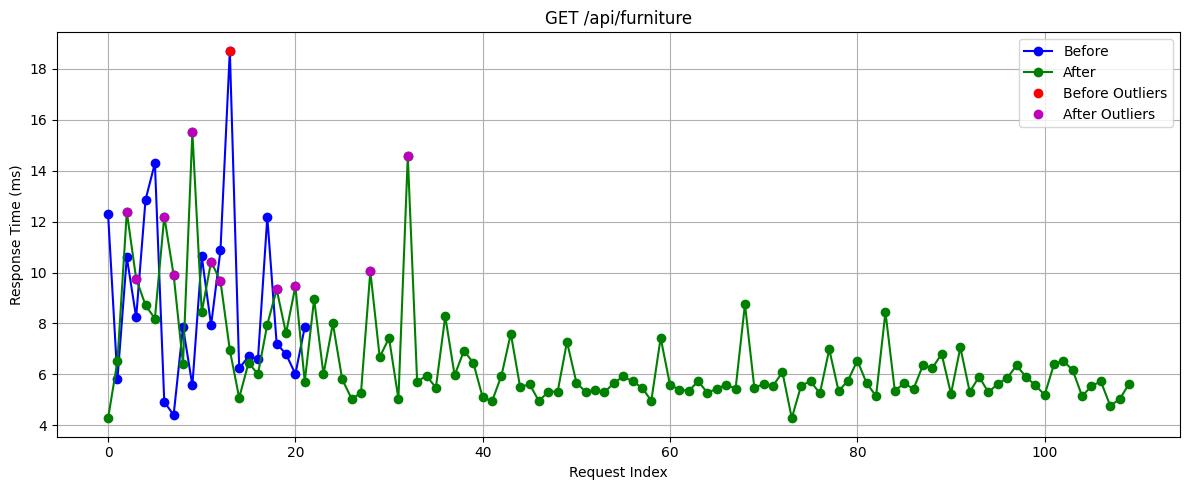


Endpoint: GET /api/furniture
Before Robust Mean: 8.374 ms
After Robust Mean:  6.016 ms
Improvement:        28.15%
--------------------------------------------------


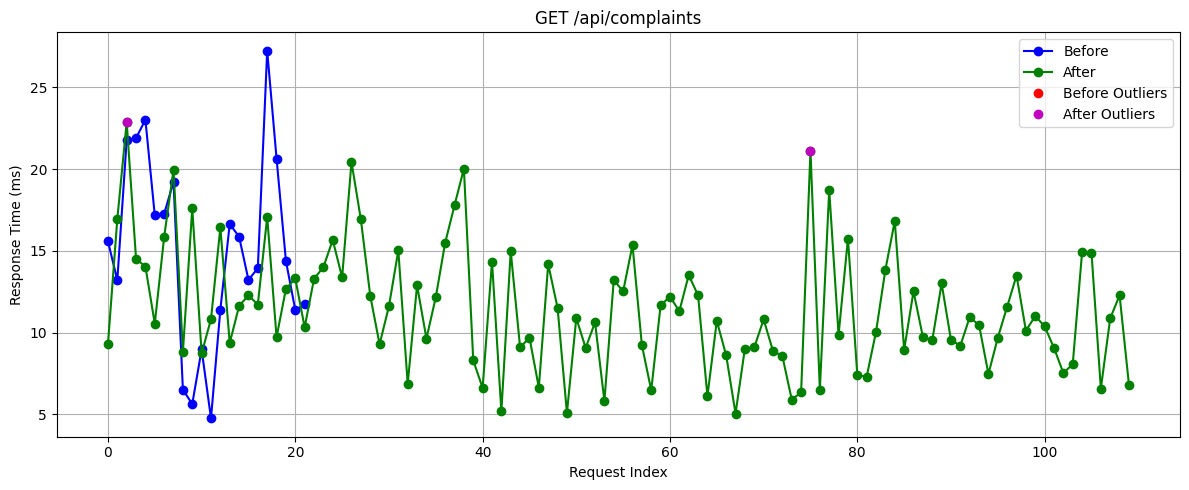


Endpoint: GET /api/complaints
Before Robust Mean: 15.061 ms
After Robust Mean:  11.312 ms
Improvement:        24.89%
--------------------------------------------------


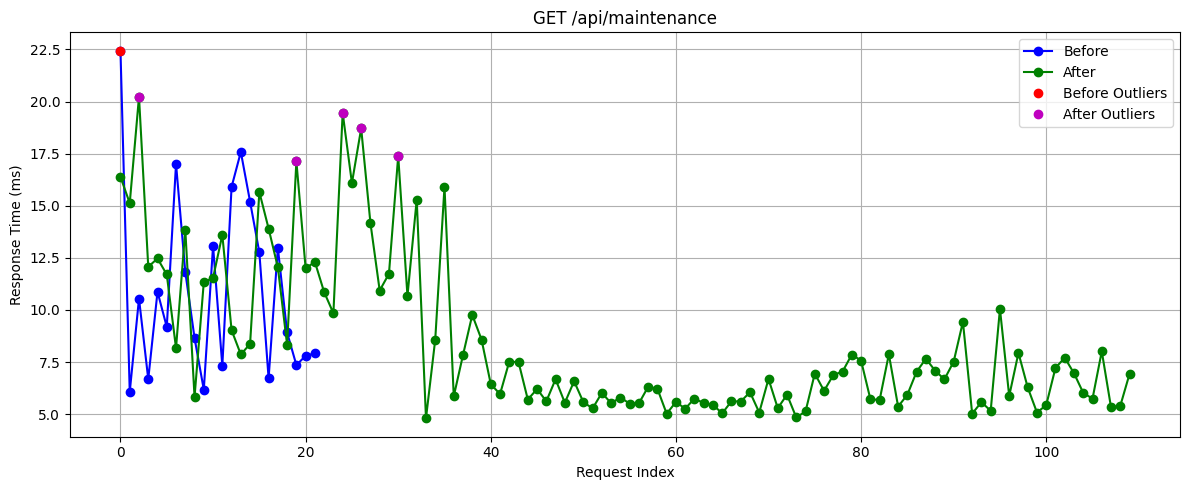


Endpoint: GET /api/maintenance
Before Robust Mean: 10.500 ms
After Robust Mean:  7.904 ms
Improvement:        24.73%
--------------------------------------------------


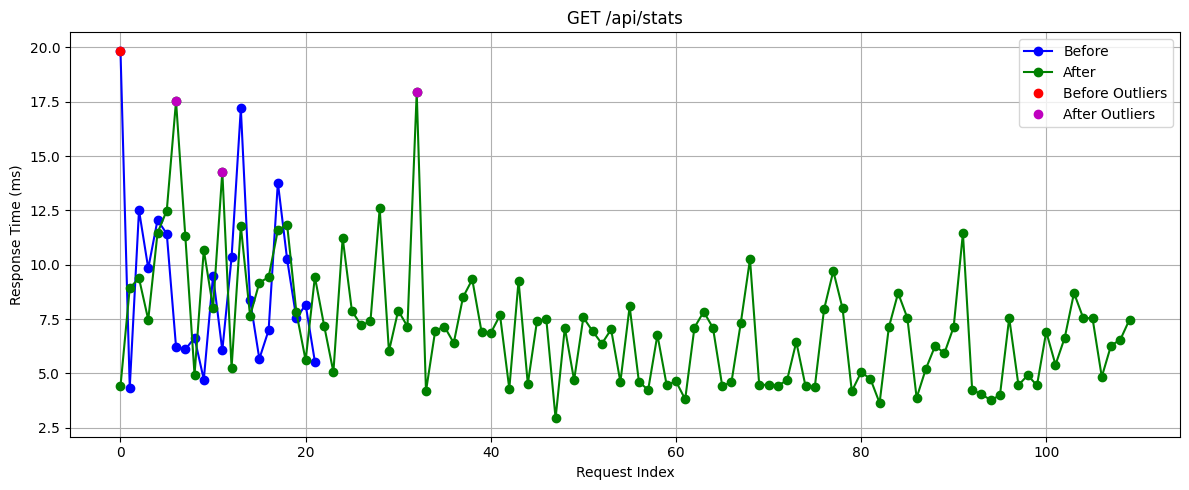


Endpoint: GET /api/stats
Before Robust Mean: 8.724 ms
After Robust Mean:  6.847 ms
Improvement:        21.51%
--------------------------------------------------


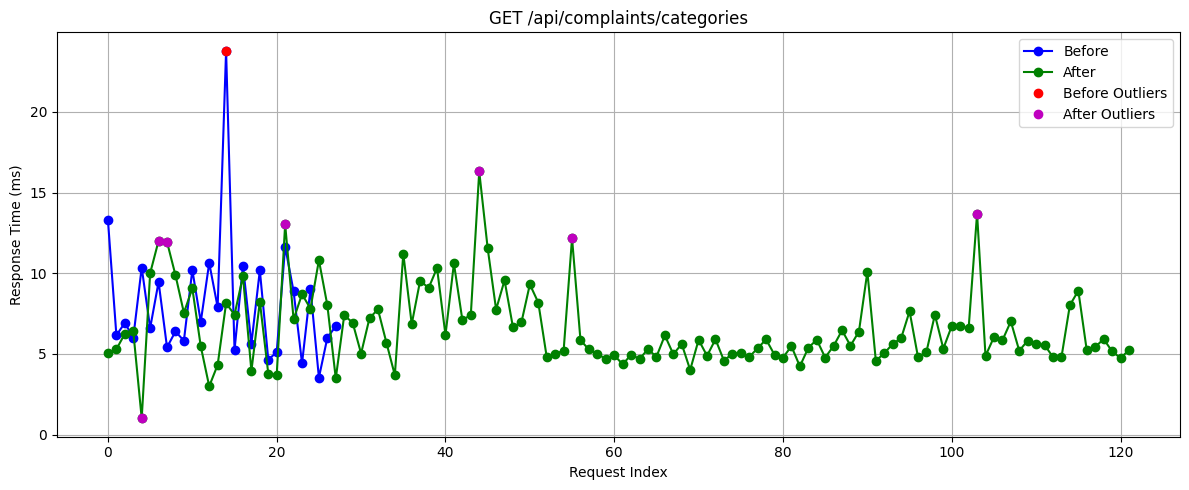


Endpoint: GET /api/complaints/categories
Before Robust Mean: 7.543 ms
After Robust Mean:  6.292 ms
Improvement:        16.58%
--------------------------------------------------


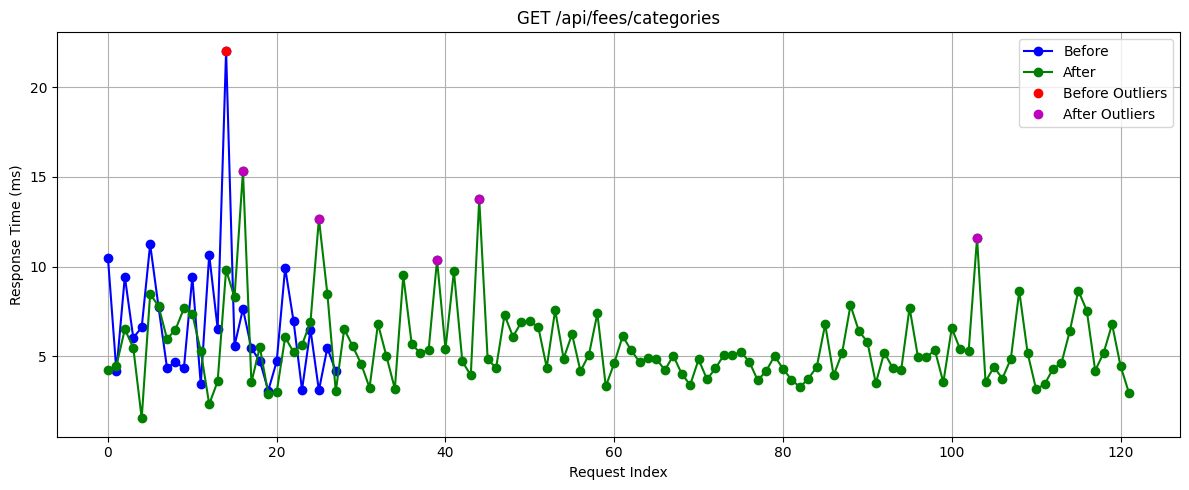


Endpoint: GET /api/fees/categories
Before Robust Mean: 6.286 ms
After Robust Mean:  5.285 ms
Improvement:        15.93%
--------------------------------------------------


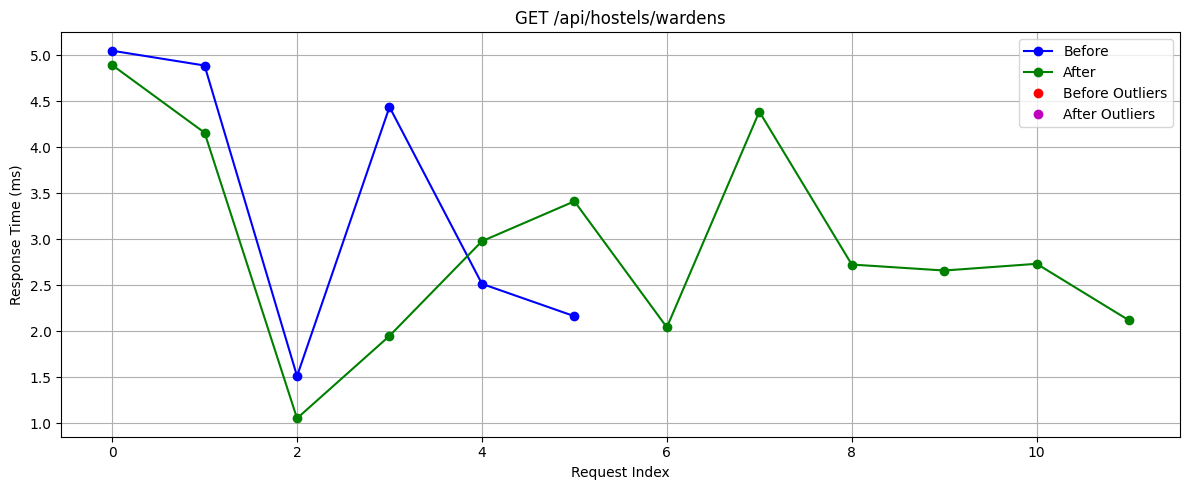


Endpoint: GET /api/hostels/wardens
Before Robust Mean: 3.428 ms
After Robust Mean:  2.926 ms
Improvement:        14.65%
--------------------------------------------------


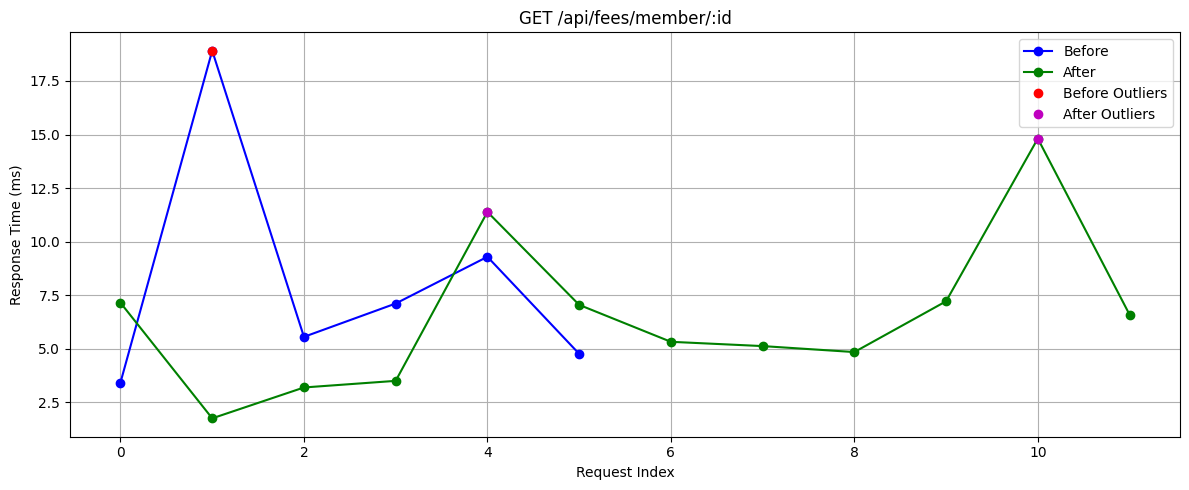


Endpoint: GET /api/fees/member/:id
Before Robust Mean: 6.023 ms
After Robust Mean:  5.167 ms
Improvement:        14.20%
--------------------------------------------------


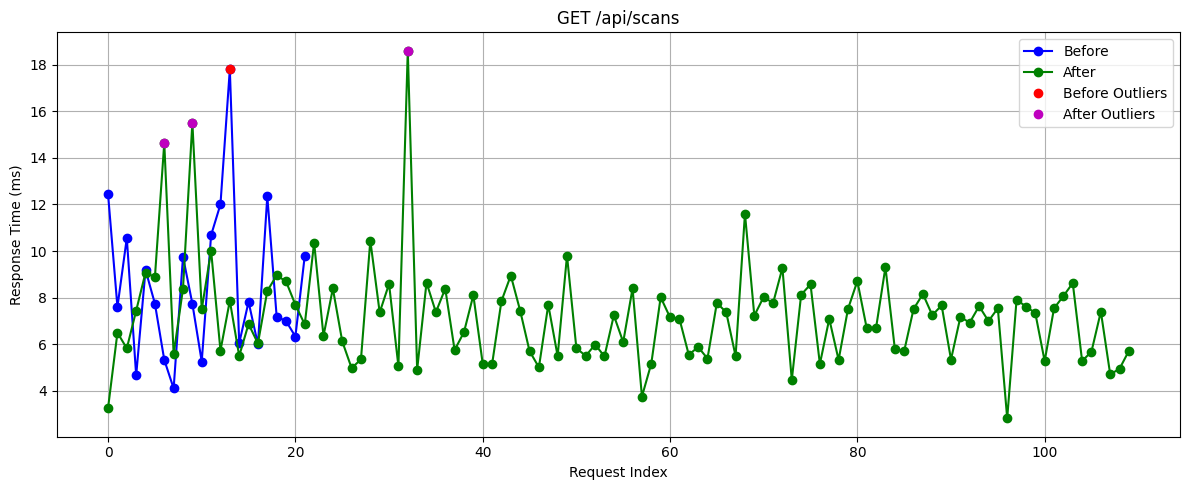


Endpoint: GET /api/scans
Before Robust Mean: 8.073 ms
After Robust Mean:  6.944 ms
Improvement:        13.98%
--------------------------------------------------


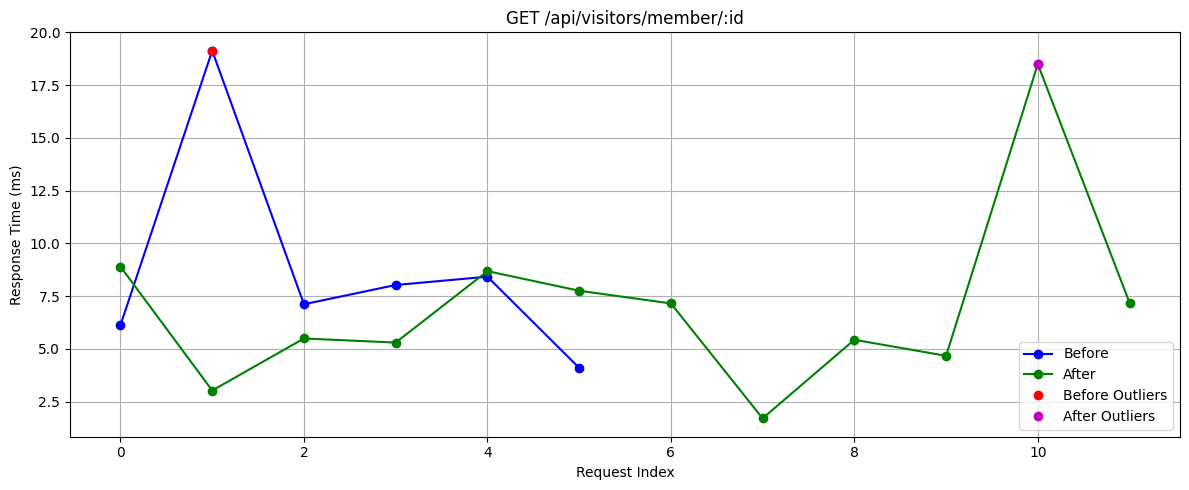


Endpoint: GET /api/visitors/member/:id
Before Robust Mean: 6.759 ms
After Robust Mean:  5.939 ms
Improvement:        12.14%
--------------------------------------------------


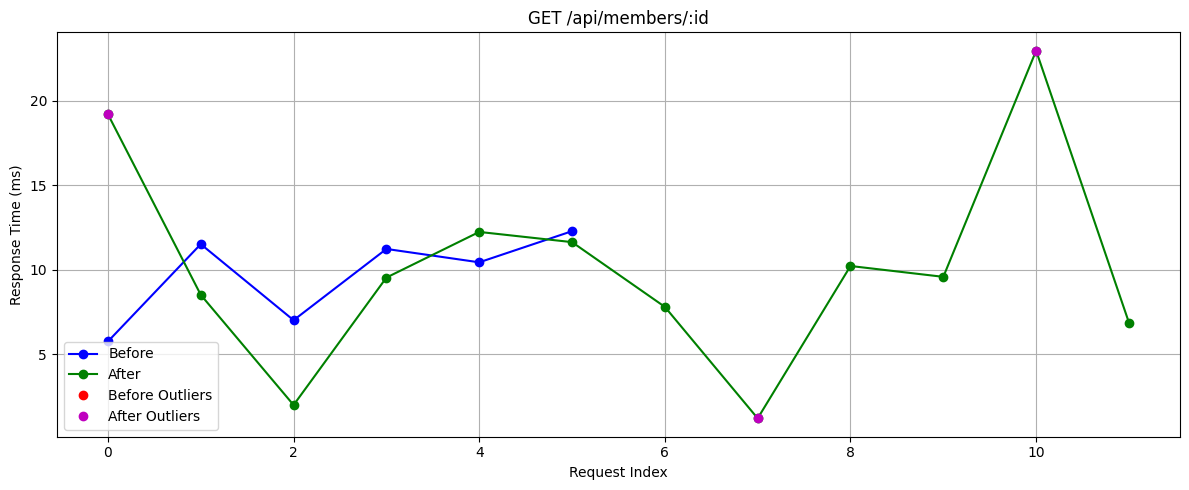


Endpoint: GET /api/members/:id
Before Robust Mean: 9.704 ms
After Robust Mean:  8.707 ms
Improvement:        10.27%
--------------------------------------------------


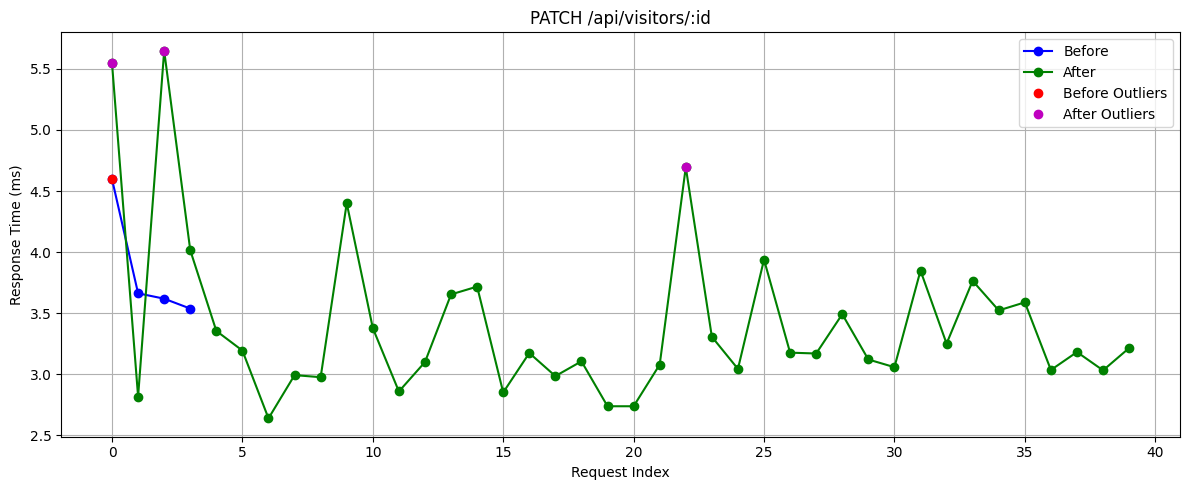


Endpoint: PATCH /api/visitors/:id
Before Robust Mean: 3.606 ms
After Robust Mean:  3.256 ms
Improvement:        9.69%
--------------------------------------------------


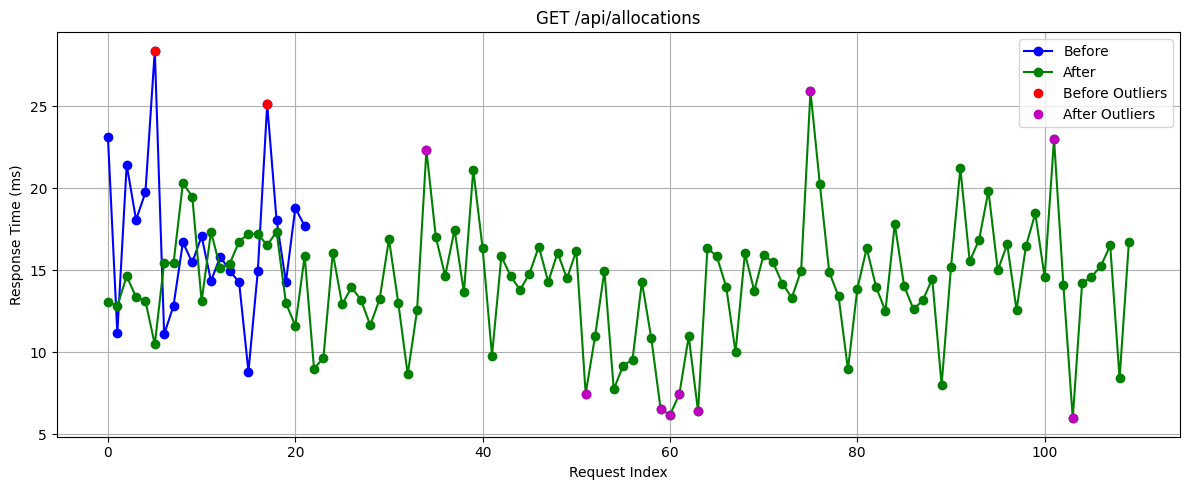


Endpoint: GET /api/allocations
Before Robust Mean: 15.926 ms
After Robust Mean:  14.416 ms
Improvement:        9.48%
--------------------------------------------------


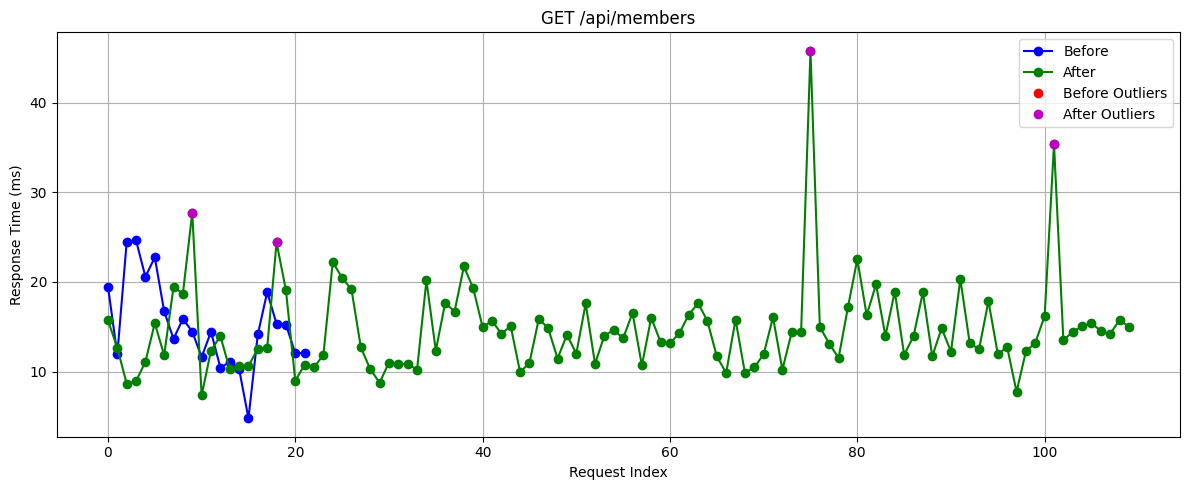


Endpoint: GET /api/members
Before Robust Mean: 15.225 ms
After Robust Mean:  14.004 ms
Improvement:        8.02%
--------------------------------------------------


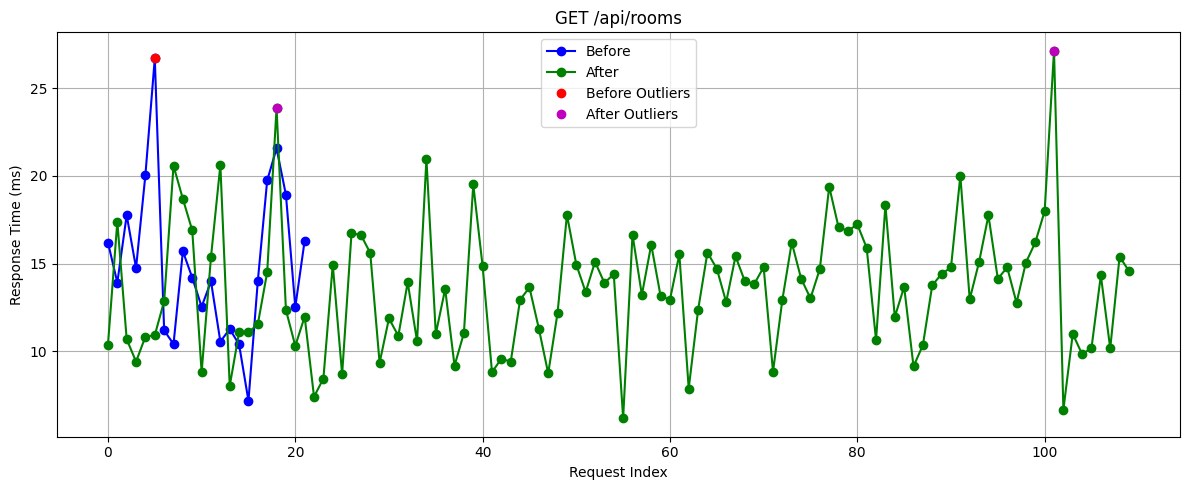


Endpoint: GET /api/rooms
Before Robust Mean: 14.432 ms
After Robust Mean:  13.353 ms
Improvement:        7.47%
--------------------------------------------------


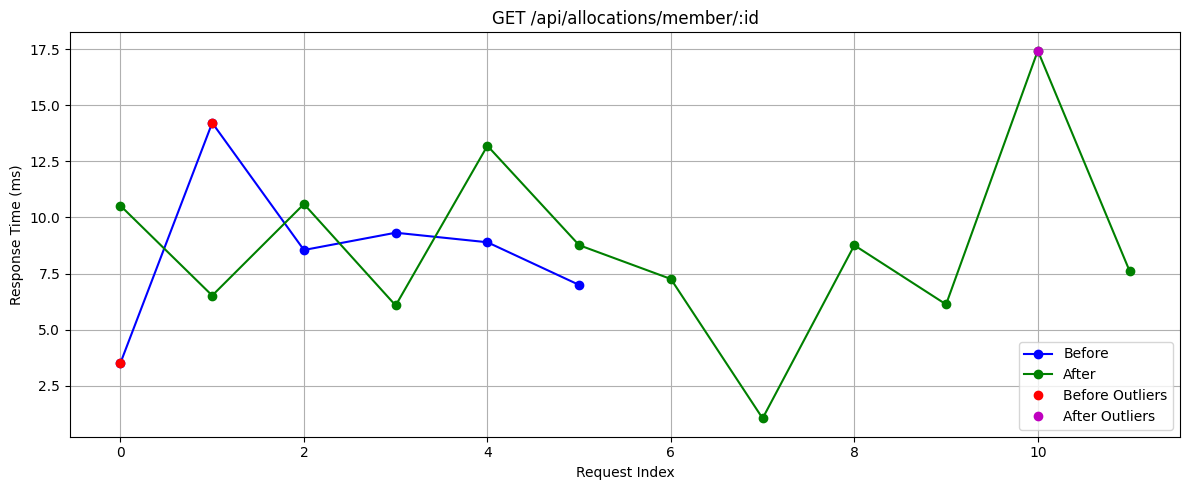


Endpoint: GET /api/allocations/member/:id
Before Robust Mean: 8.440 ms
After Robust Mean:  7.863 ms
Improvement:        6.83%
--------------------------------------------------


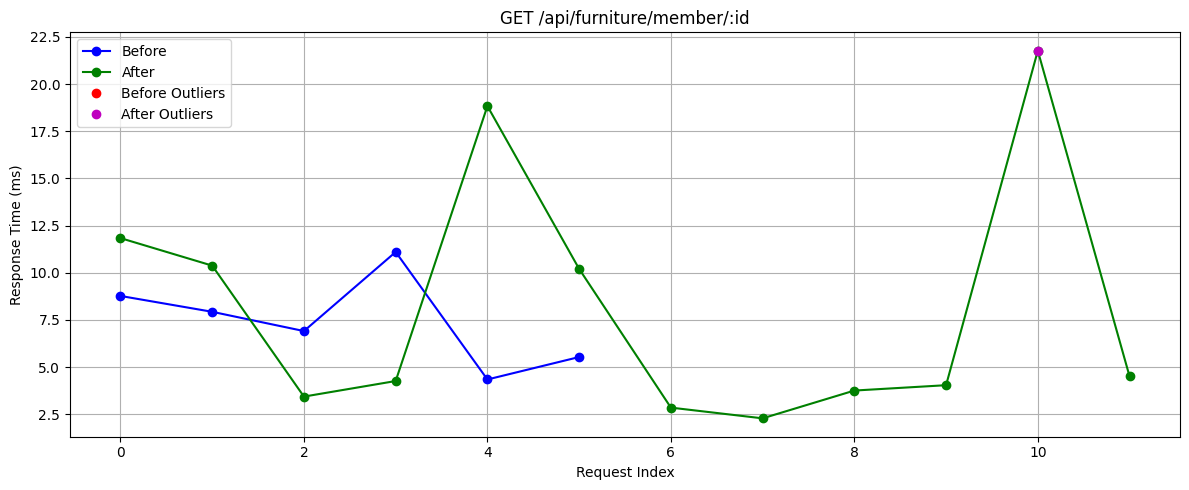


Endpoint: GET /api/furniture/member/:id
Before Robust Mean: 7.434 ms
After Robust Mean:  6.948 ms
Improvement:        6.54%
--------------------------------------------------


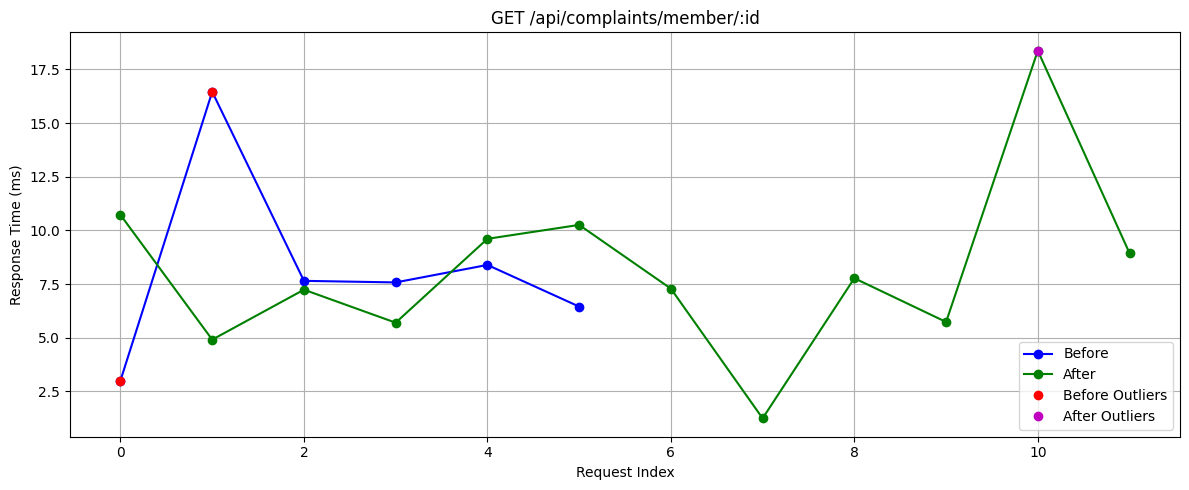


Endpoint: GET /api/complaints/member/:id
Before Robust Mean: 7.519 ms
After Robust Mean:  7.221 ms
Improvement:        3.96%
--------------------------------------------------


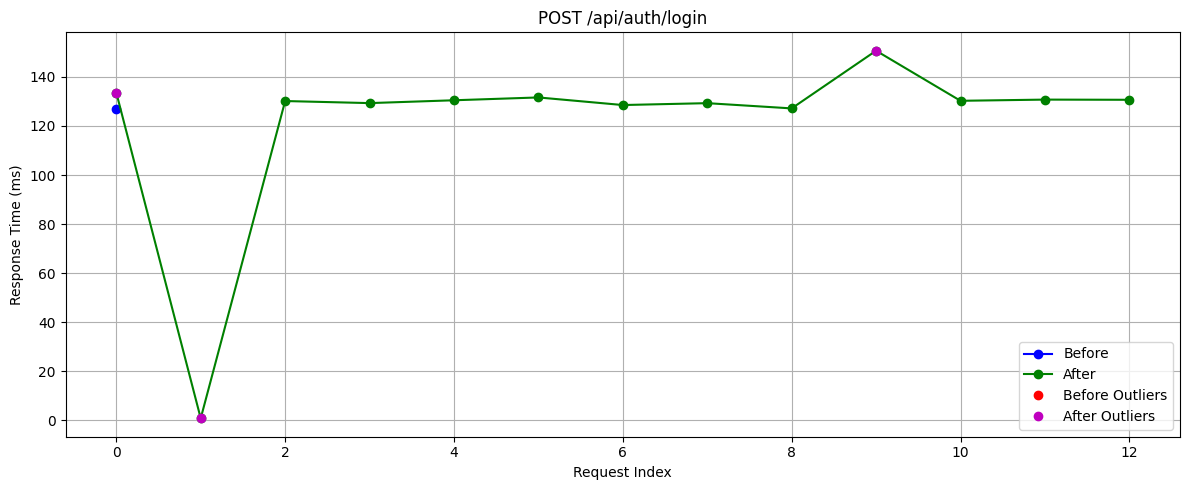


Endpoint: POST /api/auth/login
Before Robust Mean: 126.825 ms
After Robust Mean:  129.823 ms
Improvement:        -2.36%
--------------------------------------------------


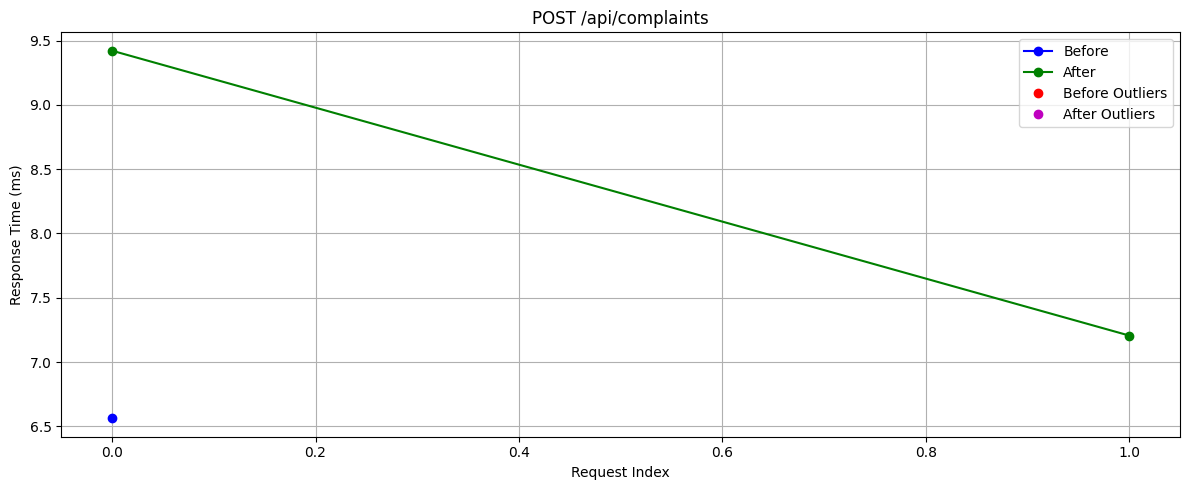


Endpoint: POST /api/complaints
Before Robust Mean: 6.562 ms
After Robust Mean:  8.313 ms
Improvement:        -26.69%
--------------------------------------------------


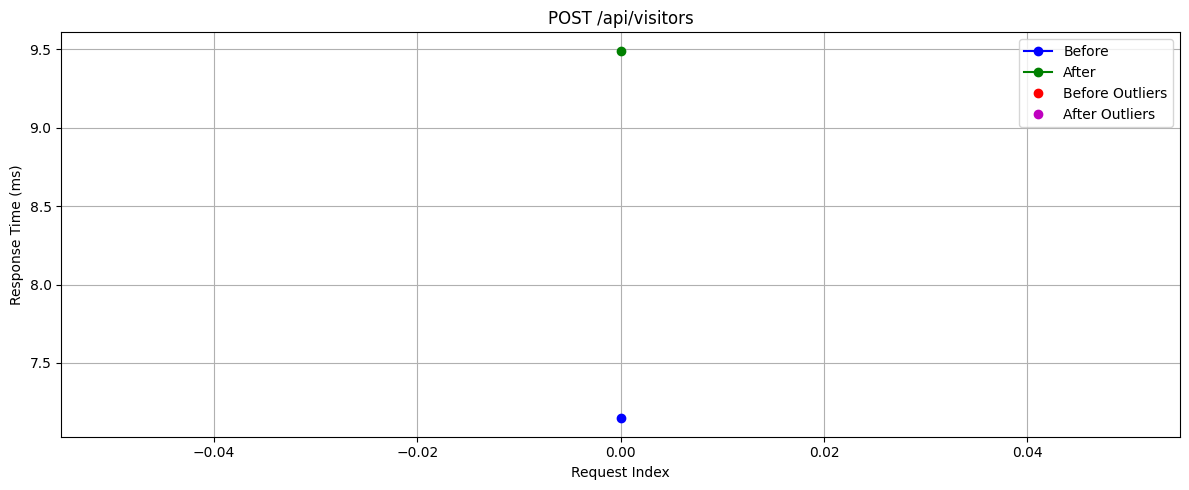


Endpoint: POST /api/visitors
Before Robust Mean: 7.146 ms
After Robust Mean:  9.492 ms
Improvement:        -32.83%
--------------------------------------------------


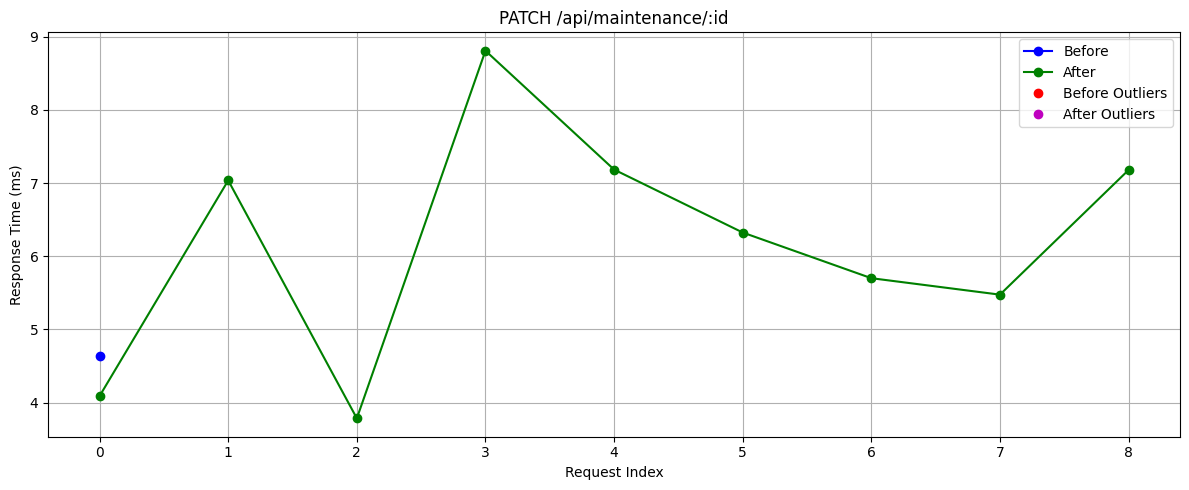


Endpoint: PATCH /api/maintenance/:id
Before Robust Mean: 4.631 ms
After Robust Mean:  6.177 ms
Improvement:        -33.37%
--------------------------------------------------


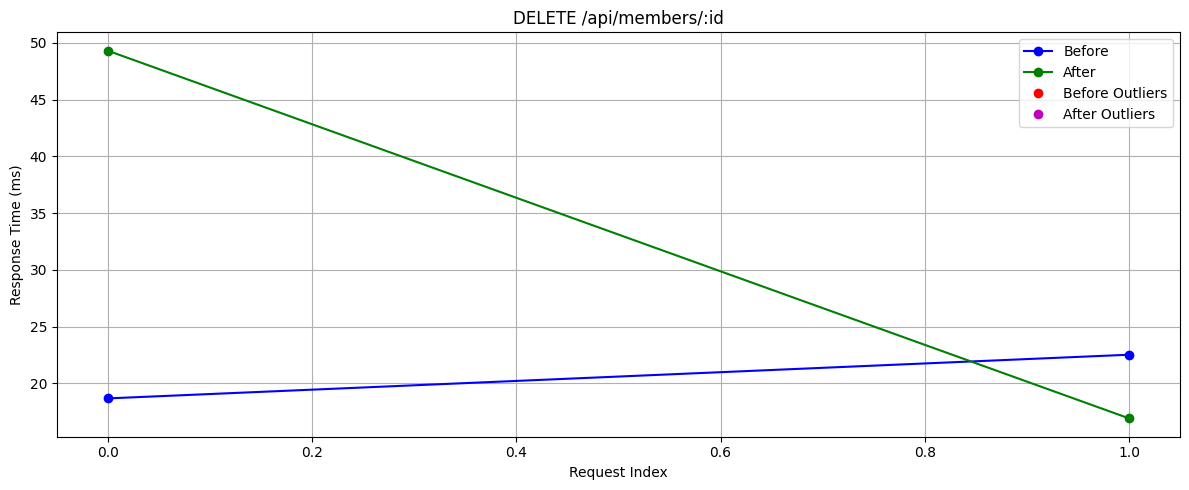


Endpoint: DELETE /api/members/:id
Before Robust Mean: 20.595 ms
After Robust Mean:  33.111 ms
Improvement:        -60.77%
--------------------------------------------------


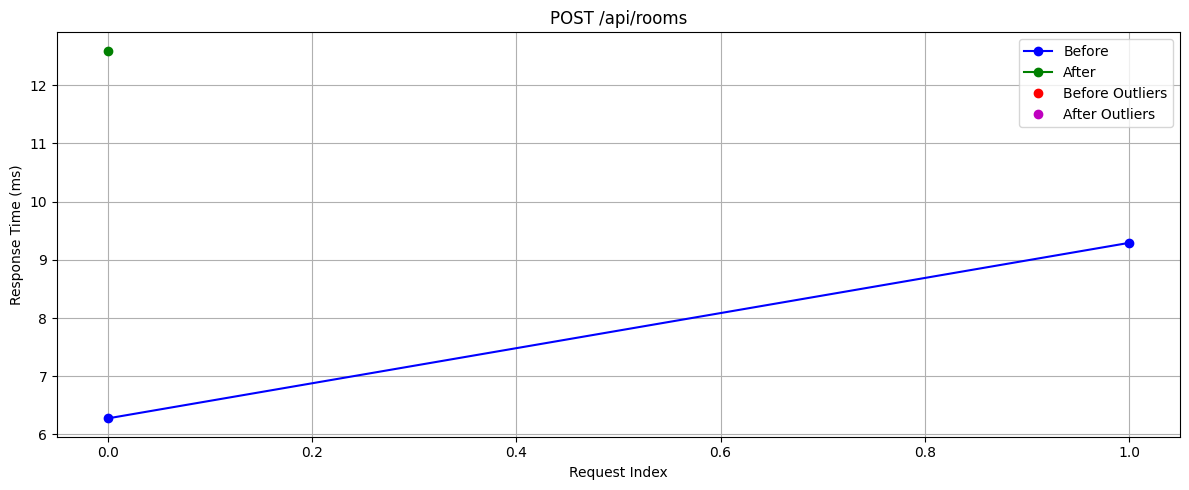


Endpoint: POST /api/rooms
Before Robust Mean: 7.784 ms
After Robust Mean:  12.593 ms
Improvement:        -61.79%
--------------------------------------------------


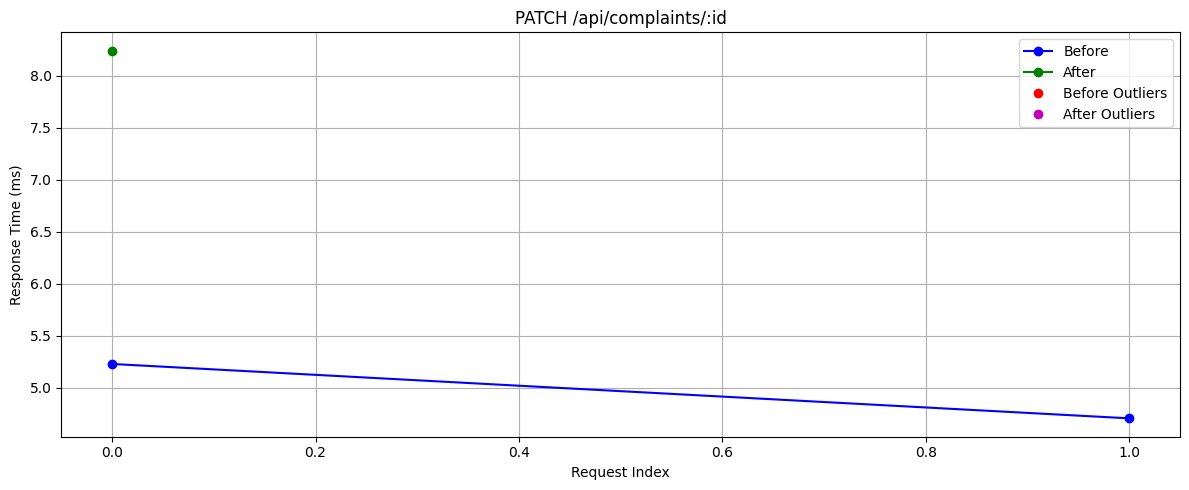


Endpoint: PATCH /api/complaints/:id
Before Robust Mean: 4.966 ms
After Robust Mean:  8.241 ms
Improvement:        -65.93%
--------------------------------------------------


In [ ]:
# ✅ CALL THIS
plot_comparison_lines(df_compare_sorted)

#Overall API Performance and Improvement Visualization

This section compares API performance between the Before and After logs by merging the processed datasets based on the API endpoint. It calculates the percentage improvement for multiple metrics, including mean response time, robust mean, median, and 95th percentile latency. The results are sorted by robust mean improvement and saved to benchmark_comparison.csv for further analysis.

Two visualization functions are used. The first graph shows the robust mean response time of all APIs before and after optimization, allowing a direct comparison of performance changes. The second graph displays the percentage improvement for each API endpoint, helping identify which endpoints benefited the most from the optimization (such as indexing).

These visualizations provide a clear overview of system performance improvements and remaining bottlenecks across all APIs.

In [ ]:
# Load both logs
df_before = process_log("Before.log")
df_after = process_log("After.log")

In [ ]:
# Merge
df_compare = pd.merge(
    df_before,
    df_after,
    on="MethodEndpoint",
    suffixes=("_Before", "_After")
)

In [ ]:
# Compute improvements
df_compare["Mean_Improvement_%"] = (
    (df_compare["Mean_Before"] - df_compare["Mean_After"]) /
    df_compare["Mean_Before"]
) * 100

df_compare["RobustMean_Improvement_%"] = (
    (df_compare["RobustMean_Before"] - df_compare["RobustMean_After"]) /
    df_compare["RobustMean_Before"]
) * 100

df_compare["Median_Improvement_%"] = (
    (df_compare["Median_Before"] - df_compare["Median_After"]) /
    df_compare["Median_Before"]
) * 100

df_compare["P95_Improvement_%"] = (
    (df_compare["P95_Before"] - df_compare["P95_After"]) /
    df_compare["P95_Before"]
) * 100

In [ ]:
# Sort by improvement
df_compare_sorted = df_compare.sort_values(
    by="RobustMean_Improvement_%",
    ascending=False
)

In [ ]:
# Print results
print("\n=== PERFORMANCE COMPARISON (Before vs After) ===\n")
print(df_compare_sorted[[
    "MethodEndpoint",
    "Count_Before", "Count_After",
    "Mean_Before", "Mean_After", "Mean_Improvement_%",
    "RobustMean_Before", "RobustMean_After", "RobustMean_Improvement_%",
    "Median_Before", "Median_After", "Median_Improvement_%",
    "P95_Before", "P95_After", "P95_Improvement_%"
]])


=== PERFORMANCE COMPARISON (Before vs After) ===

                     MethodEndpoint  Count_Before  Count_After  Mean_Before  \
29            POST /api/auth/logout             1           12     2.621000   
2                     GET /api/fees            22          110    12.232045   
28      POST /api/scans/maintenance             1            4     8.960000   
25  GET /api/maintenance/member/:id             6           12     8.760333   
4                 GET /api/visitors            22          110    13.297727   
12             GET /api/rooms/types            22          110     4.574227   
27             POST /api/scans/gate             2            5     6.104000   
13                 GET /api/hostels            22          110     5.095682   
8                GET /api/furniture            22          110     8.843864   
3               GET /api/complaints            22          110    15.060727   
11             GET /api/maintenance            22          110    11.042955   
1

In [ ]:
# Save CSV
df_compare_sorted.to_csv("benchmark_comparison.csv", index=False)
print("\nSaved: benchmark_comparison.csv")


Saved: benchmark_comparison.csv


In [ ]:
# =========================
# 📊 SINGLE COMBINED GRAPH
# =========================
def plot_all_apis_combined(df):
    df = df.sort_values(by="RobustMean_Before", ascending=False)

    x = np.arange(len(df))

    plt.figure(figsize=(16, 7))

    plt.plot(x, df["RobustMean_Before"], marker='o', label="Before", color='blue')
    plt.plot(x, df["RobustMean_After"], marker='o', label="After", color='green')

    plt.xticks(x, df["MethodEndpoint"], rotation=75, ha='right')
    plt.ylabel("Robust Mean Response Time (ms)")
    plt.title("API Performance Comparison (Before vs After Indexing)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
# =========================
# 📈 IMPROVEMENT GRAPH
# =========================
def plot_improvement(df):
    df = df.sort_values(by="RobustMean_Improvement_%", ascending=False)

    x = np.arange(len(df))

    plt.figure(figsize=(16, 7))

    plt.plot(x, df["RobustMean_Improvement_%"], marker='o', color='purple')

    plt.axhline(0, color='red', linestyle='--')

    plt.xticks(x, df["MethodEndpoint"], rotation=75, ha='right')
    plt.ylabel("Improvement (%)")
    plt.title("API Performance Improvement After Indexing")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

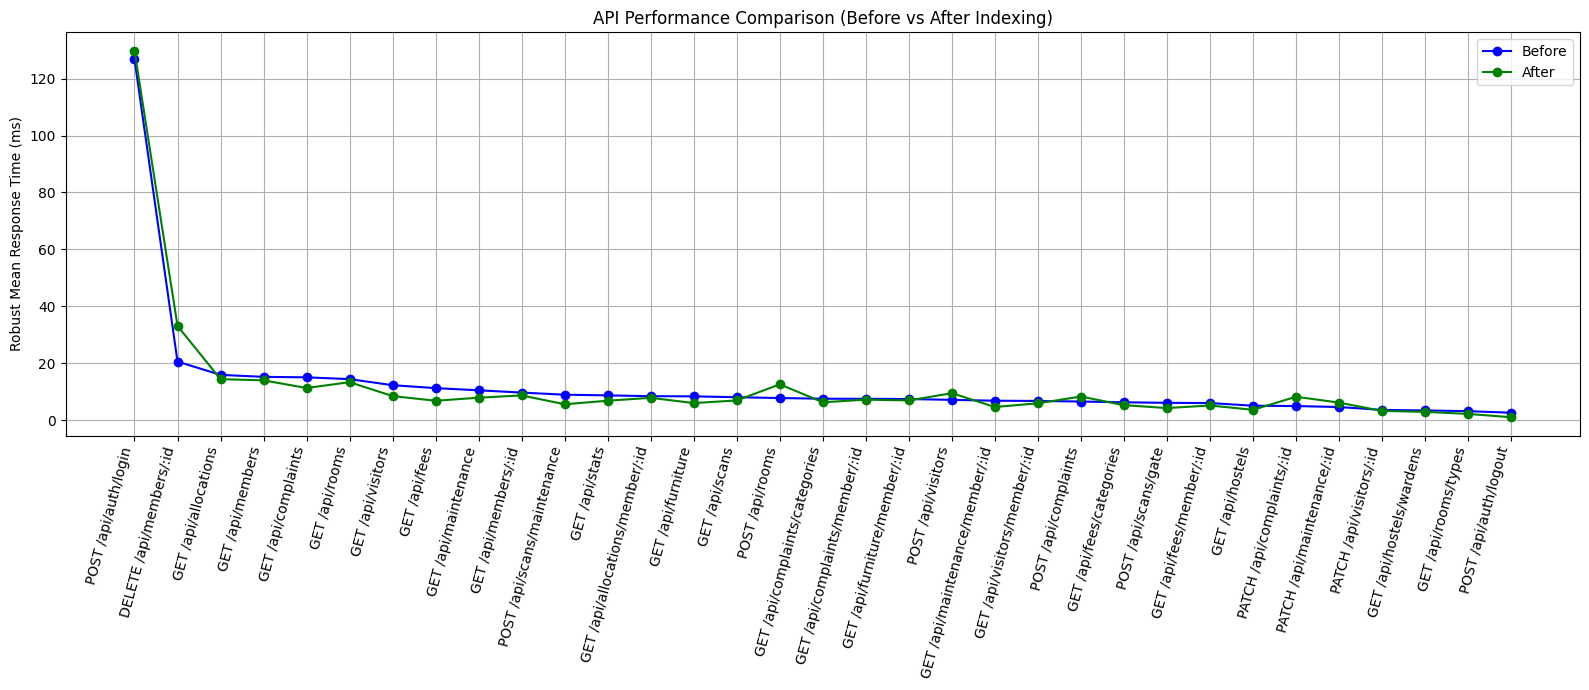

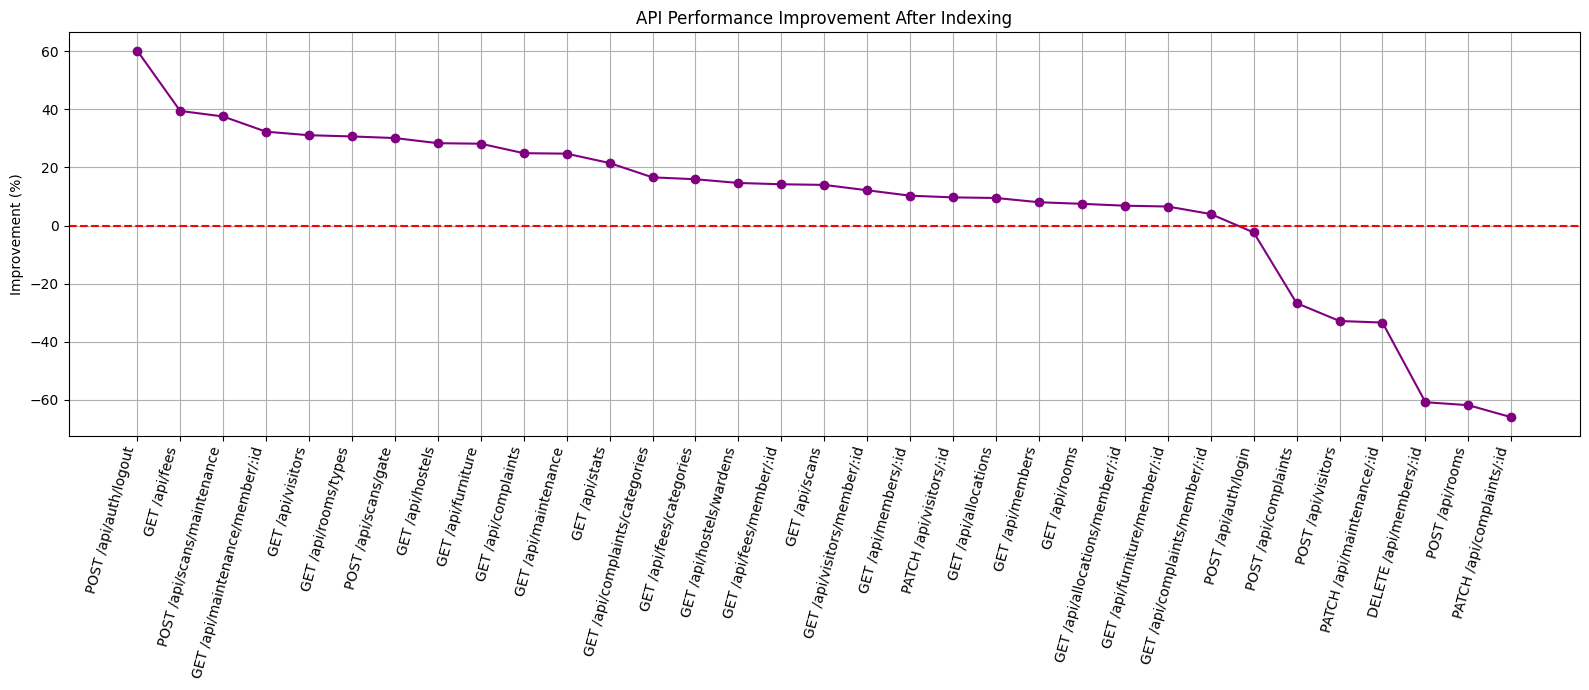

In [ ]:
# =========================
# 🚀 RUN PLOTS
# =========================
plot_all_apis_combined(df_compare_sorted)
plot_improvement(df_compare_sorted)

#Comprehensive API Performance Analysis


This section performs a detailed comparison of API performance between the Before.log and After.log datasets. The logs are processed, merged by API endpoint, and several performance metrics (mean, robust mean, median, and 95th percentile) are compared to calculate percentage improvements after optimization. The final comparison results are printed and saved to benchmark_comparison.csv.

Multiple visualizations are then generated to better understand performance changes, including combined line graphs, improvement plots, box plots, histograms, top improved APIs, worst performing APIs, scatter plots, and CDF plots. These graphs help analyze latency distribution, overall performance improvement, and remaining bottlenecks across all API endpoints.

In [ ]:
# =========================
# 📂 PROCESS LOG FILE
# =========================
def process_log(log_file_path):
    api_data = {}

    with open(log_file_path, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                method = match.group(1)
                endpoint = match.group(2)
                response_time = float(match.group(4))

                if not endpoint.startswith("/api/"):
                    continue

                endpoint_norm = normalize_endpoint(endpoint)
                key = f"{method} {endpoint_norm}"

                api_data.setdefault(key, []).append(response_time)
    data = []
    for key, times in api_data.items():
        times_array = np.array(times)

        q1, q3 = np.percentile(times_array, [25, 75])
        iqr = q3 - q1

        filtered = times_array[
            (times_array >= q1 - 1.5 * iqr) &
            (times_array <= q3 + 1.5 * iqr)
        ]

        data.append({
            "MethodEndpoint": key,
            "Count": len(times),
            "Mean": times_array.mean(),
            "RobustMean": filtered.mean() if len(filtered) > 0 else np.nan,
            "Median": np.median(times_array),
            "P95": np.percentile(times_array, 95),
            "AllTimes": times_array
        })

    return pd.DataFrame(data)

In [ ]:
# =========================
# 🚀 LOAD LOGS
# =========================
df_before = process_log("Before.log")
df_after = process_log("After.log")

In [ ]:
# =========================
# 🔗 MERGE + COMPARE
# =========================
df_compare = pd.merge(
    df_before,
    df_after,
    on="MethodEndpoint",
    suffixes=("_Before", "_After")
)

In [ ]:
# =========================
# 📊 IMPROVEMENTS
# =========================
df_compare["Mean_Improvement_%"] = (
    (df_compare["Mean_Before"] - df_compare["Mean_After"]) /
    df_compare["Mean_Before"]
) * 100

df_compare["RobustMean_Improvement_%"] = (
    (df_compare["RobustMean_Before"] - df_compare["RobustMean_After"]) /
    df_compare["RobustMean_Before"]
) * 100

df_compare["Median_Improvement_%"] = (
    (df_compare["Median_Before"] - df_compare["Median_After"]) /
    df_compare["Median_Before"]
) * 100

df_compare["P95_Improvement_%"] = (
    (df_compare["P95_Before"] - df_compare["P95_After"]) /
    df_compare["P95_Before"]
) * 100

In [ ]:
# Sort
df_compare_sorted = df_compare.sort_values(
    by="RobustMean_Improvement_%",
    ascending=False
)

In [ ]:
# =========================
# 🖨️ PRINT + SAVE
# =========================
print("\n=== PERFORMANCE COMPARISON (Before vs After) ===\n")
print(df_compare_sorted[[
    "MethodEndpoint",
    "Count_Before", "Count_After",
    "Mean_Before", "Mean_After", "Mean_Improvement_%",
    "RobustMean_Before", "RobustMean_After", "RobustMean_Improvement_%",
    "Median_Before", "Median_After", "Median_Improvement_%",
    "P95_Before", "P95_After", "P95_Improvement_%"
]])


=== PERFORMANCE COMPARISON (Before vs After) ===

                     MethodEndpoint  Count_Before  Count_After  Mean_Before  \
29            POST /api/auth/logout             1           12     2.621000   
2                     GET /api/fees            22          110    12.232045   
28      POST /api/scans/maintenance             1            4     8.960000   
25  GET /api/maintenance/member/:id             6           12     8.760333   
4                 GET /api/visitors            22          110    13.297727   
12             GET /api/rooms/types            22          110     4.574227   
27             POST /api/scans/gate             2            5     6.104000   
13                 GET /api/hostels            22          110     5.095682   
8                GET /api/furniture            22          110     8.843864   
3               GET /api/complaints            22          110    15.060727   
11             GET /api/maintenance            22          110    11.042955   
1

In [ ]:
df_compare_sorted.to_csv("benchmark_comparison.csv", index=False)
print("\nSaved: benchmark_comparison.csv")


Saved: benchmark_comparison.csv


In [ ]:
# =========================
# 📈 GRAPHS
# =========================

# 1. Combined Line Graph
def plot_all_apis_combined(df):
    df = df.sort_values(by="RobustMean_Before", ascending=False)
    x = np.arange(len(df))

    plt.figure(figsize=(16, 7))
    plt.plot(x, df["RobustMean_Before"], marker='o', label="Before", color='blue')
    plt.plot(x, df["RobustMean_After"], marker='o', label="After", color='green')

    plt.xticks(x, df["MethodEndpoint"], rotation=75, ha='right')
    plt.ylabel("Robust Mean (ms)")
    plt.title("API Performance Comparison")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# 2. Improvement Graph
def plot_improvement(df):
    df = df.sort_values(by="RobustMean_Improvement_%", ascending=False)
    x = np.arange(len(df))

    plt.figure(figsize=(16, 7))
    plt.plot(x, df["RobustMean_Improvement_%"], marker='o', color='purple')
    plt.axhline(0, color='red', linestyle='--')

    plt.xticks(x, df["MethodEndpoint"], rotation=75, ha='right')
    plt.ylabel("Improvement (%)")
    plt.title("Performance Improvement")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# 3. Box Plot
def plot_boxplot(df):
    before, after = [], []
    for _, row in df.iterrows():
        before.extend(row["AllTimes_Before"])
        after.extend(row["AllTimes_After"])

    plt.figure(figsize=(8,6))
    plt.boxplot([before, after], labels=["Before", "After"])
    plt.title("Response Time Distribution")
    plt.ylabel("ms")
    plt.grid(True)
    plt.show()

In [ ]:
# 4. Histogram
def plot_histogram(df):
    before, after = [], []
    for _, row in df.iterrows():
        before.extend(row["AllTimes_Before"])
        after.extend(row["AllTimes_After"])

    plt.figure(figsize=(10,6))
    plt.hist(before, bins=50, alpha=0.5, label="Before")
    plt.hist(after, bins=50, alpha=0.5, label="After")

    plt.title("Latency Distribution")
    plt.xlabel("ms")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

In [ ]:
# 5. Top Improved APIs
def plot_top_improvements(df):
    df_top = df.sort_values(by="RobustMean_Improvement_%", ascending=False).head(10)

    plt.figure(figsize=(10,6))
    plt.barh(df_top["MethodEndpoint"], df_top["RobustMean_Improvement_%"], color='green')
    plt.gca().invert_yaxis()
    plt.title("Top Improved APIs")
    plt.xlabel("Improvement (%)")
    plt.grid(True)
    plt.show()

In [ ]:
# 6. Worst APIs
def plot_worst_apis(df):
    df_worst = df.sort_values(by="RobustMean_Improvement_%").head(10)

    plt.figure(figsize=(10,6))
    plt.barh(df_worst["MethodEndpoint"], df_worst["RobustMean_Improvement_%"], color='red')
    plt.gca().invert_yaxis()
    plt.title("Worst Performing APIs")
    plt.xlabel("Improvement (%)")
    plt.grid(True)
    plt.show()

In [ ]:
# 7. Scatter Plot
def plot_scatter(df):
    plt.figure(figsize=(8,8))
    plt.scatter(df["RobustMean_Before"], df["RobustMean_After"], color='purple')

    max_val = max(df["RobustMean_Before"].max(), df["RobustMean_After"].max())
    plt.plot([0, max_val], [0, max_val], 'r--')

    plt.xlabel("Before")
    plt.ylabel("After")
    plt.title("Before vs After")
    plt.grid(True)
    plt.show()

In [ ]:
# 8. CDF Plot
def plot_cdf(df):
    before, after = [], []
    for _, row in df.iterrows():
        before.extend(row["AllTimes_Before"])
        after.extend(row["AllTimes_After"])

    before = np.sort(before)
    after = np.sort(after)

    cdf_before = np.arange(len(before)) / len(before)
    cdf_after = np.arange(len(after)) / len(after)

    plt.figure(figsize=(10,6))
    plt.plot(before, cdf_before, label="Before")
    plt.plot(after, cdf_after, label="After")

    plt.xlabel("Response Time (ms)")
    plt.ylabel("CDF")
    plt.title("Cumulative Distribution")
    plt.legend()
    plt.grid(True)
    plt.show()

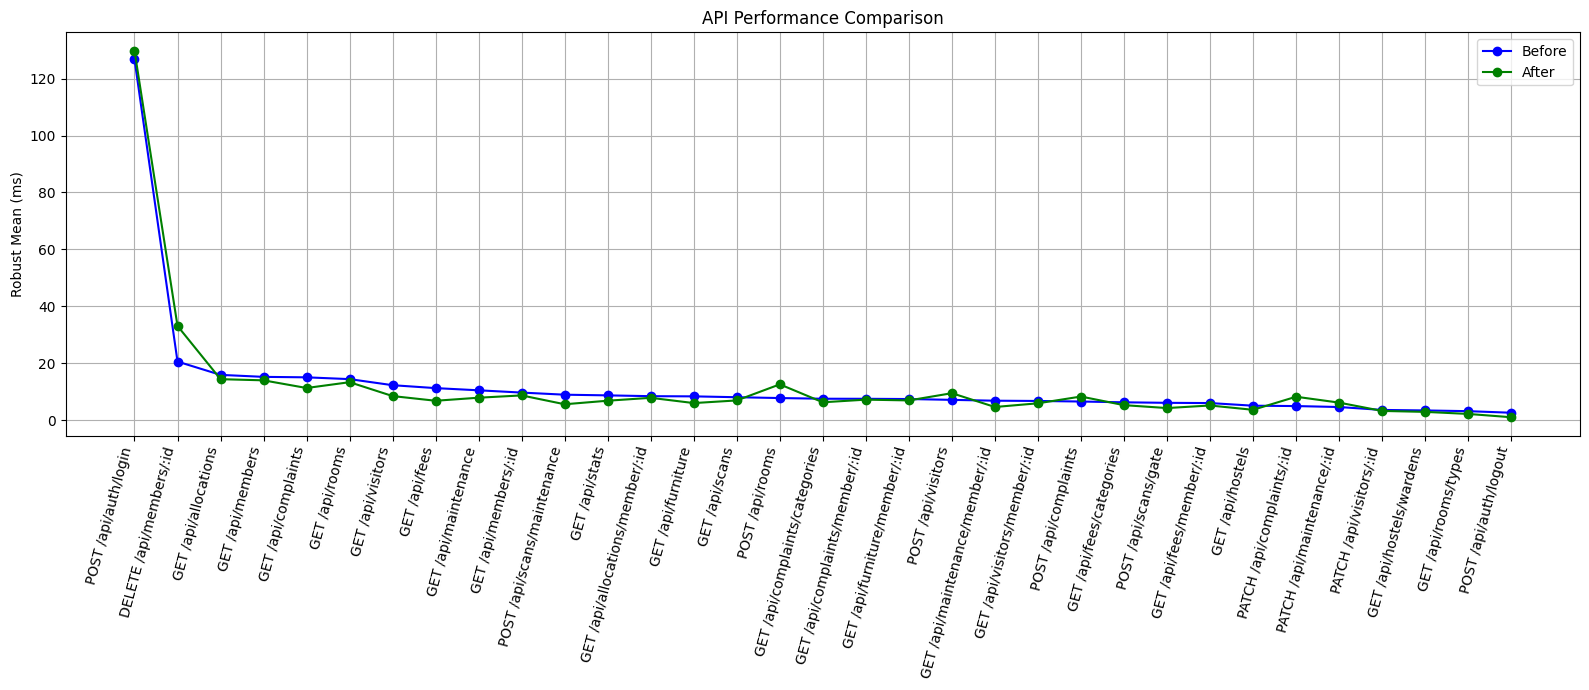

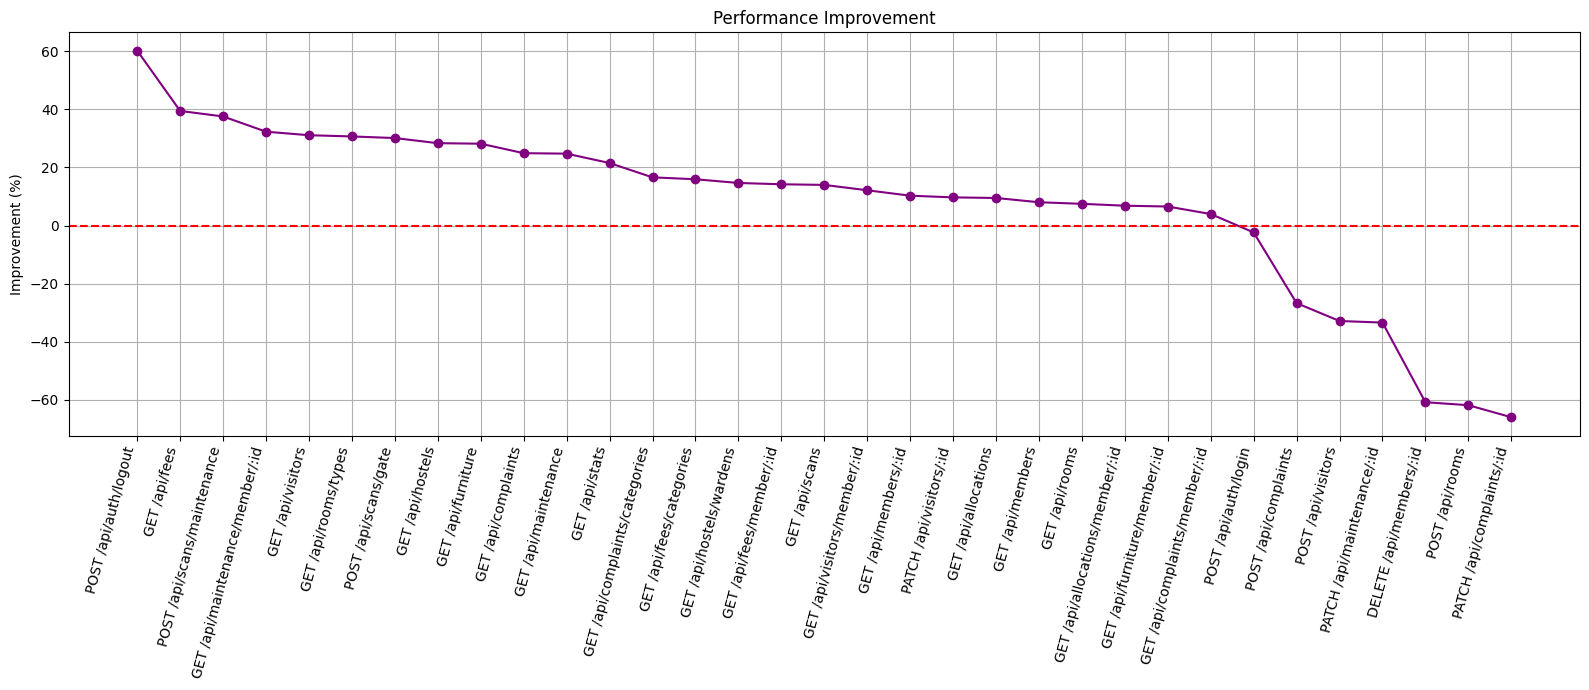

/tmp/ipykernel_2546/3079189145.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([before, after], labels=["Before", "After"])


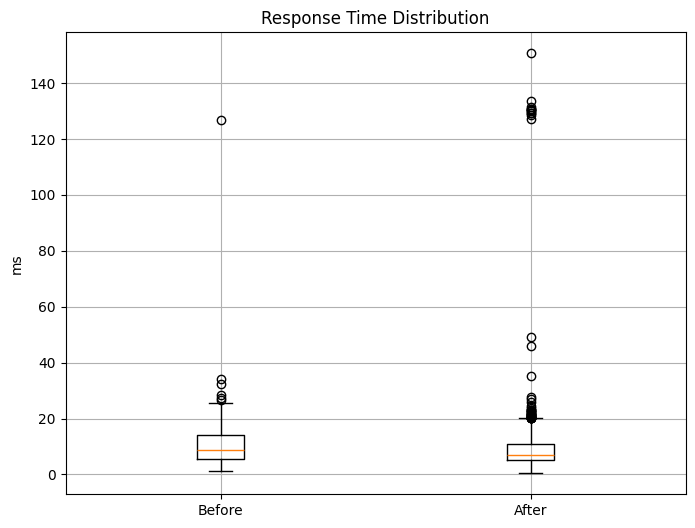

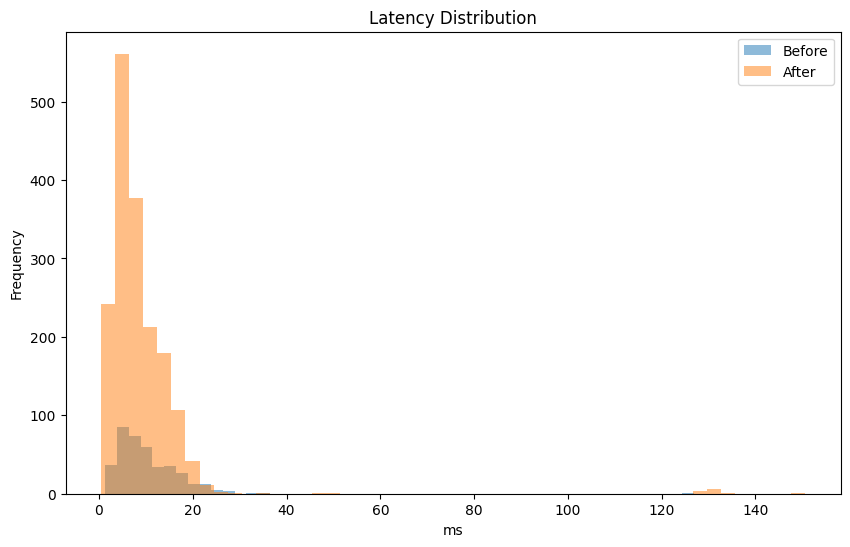

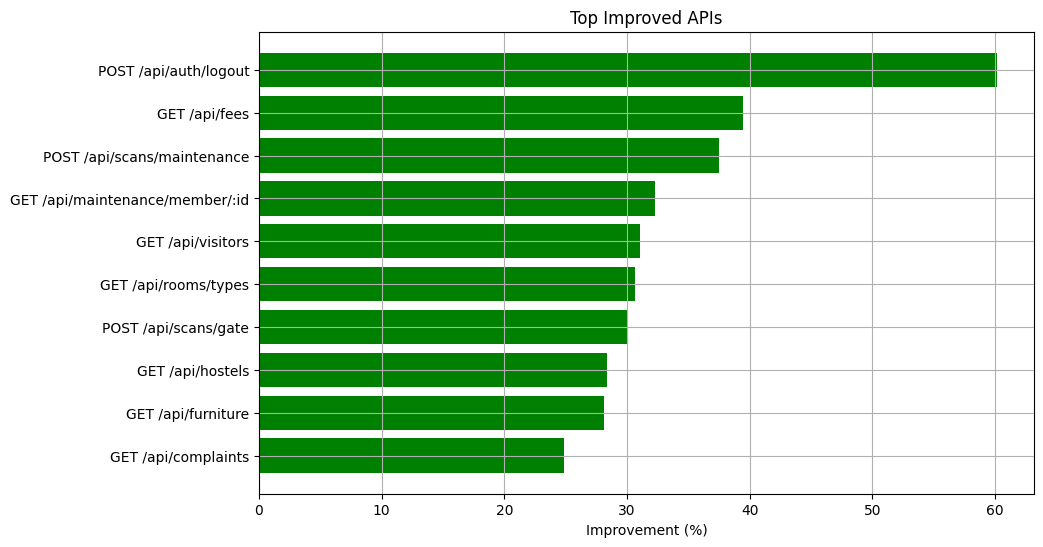

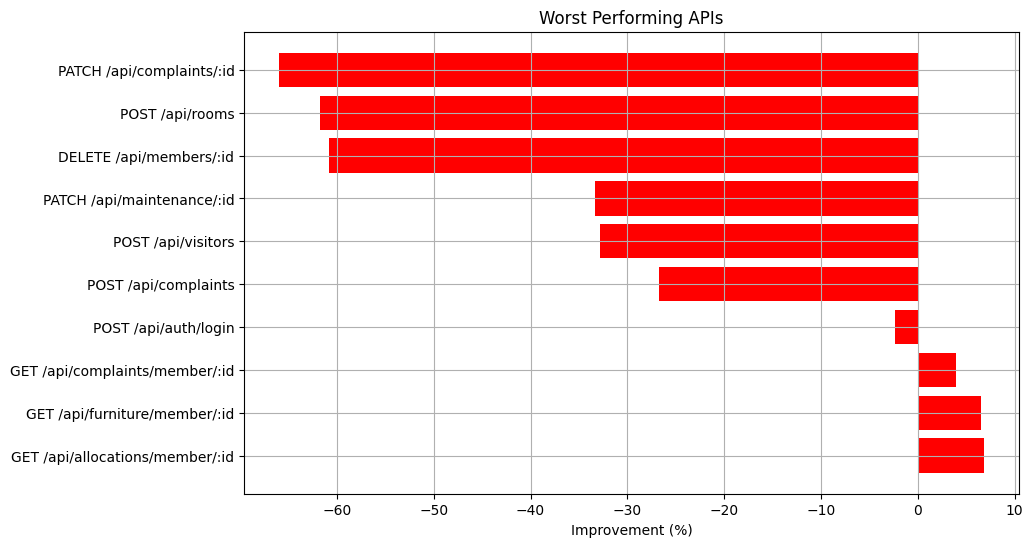

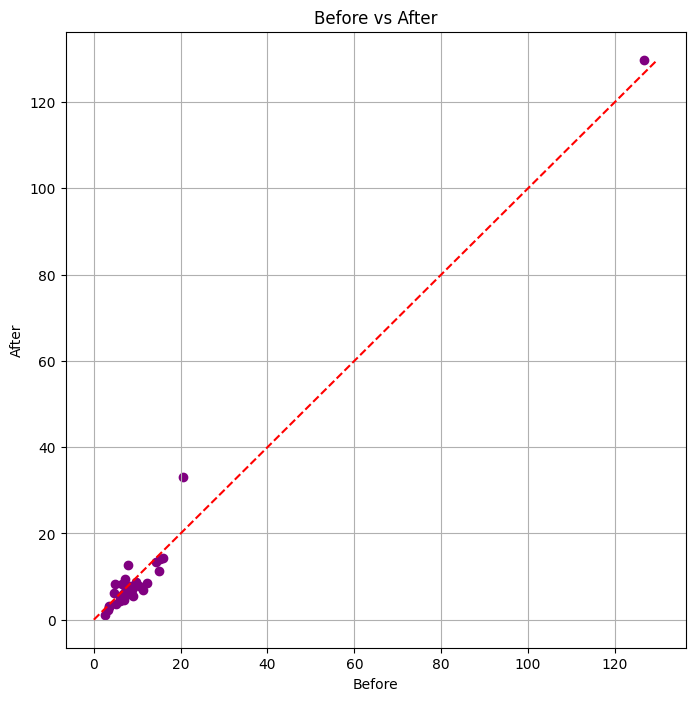

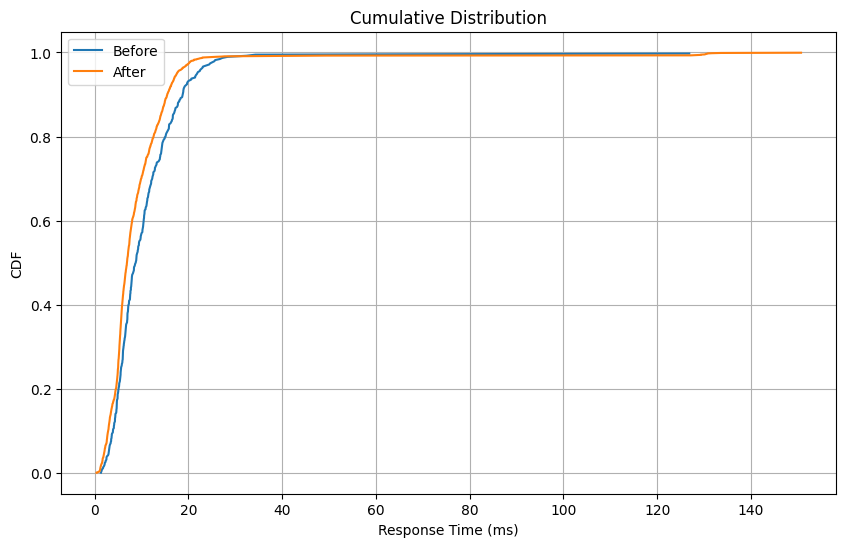

In [ ]:
# =========================
# 🚀 RUN ALL GRAPHS
# =========================
plot_all_apis_combined(df_compare_sorted)
plot_improvement(df_compare_sorted)
plot_boxplot(df_compare_sorted)
plot_histogram(df_compare_sorted)
plot_top_improvements(df_compare_sorted)
plot_worst_apis(df_compare_sorted)
plot_scatter(df_compare_sorted)
plot_cdf(df_compare_sorted)